In [1]:
import os
import numpy as np
import cv2
from PIL import Image
from matplotlib import pyplot as plt

In [2]:
pmatrix_new = np.load('./data/pmatrix_new.npy')
new_w = int(np.load('./data/new_w.npy'))
new_h = int(np.load('./data/new_h.npy'))

In [ ]:
src = r'./data/4/masks'
img_fs = [os.path.join(src, f) for f in os.listdir(src) if f.endswith('.jpg')]
msk_fs = [os.path.join(src, f) for f in os.listdir(src) if f.endswith('.npy')]

import re
coord = []

msk_fs = msk_fs  # временно для тестов

for f in msk_fs:
    match = re.search(r'(\d+\.\d{3,})', f)
    if match:
        result = match.group(1)
        coord.append(int(float(result)*1000))  # переводим координаты в мм

print('coord', coord[:10])
print('coord', msk_fs[:10])


def load_warp(mask_path):
    mask = np.load(mask_path)
    mask = np.array(mask, dtype=np.uint8)
    res = cv2.warpPerspective(mask, pmatrix_new, (new_w, new_h))
    res[:, :int(res.shape[1]/3)] = 0
    res[:, -int(res.shape[1]/3):] = 0
    return res

def resize(arr):
    # scale = 1000 / max(arr.shape)
    scale = 0.1
    display_res = cv2.resize(arr, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
    return display_res

# fig, ax = plt.subplots()

# # mask_pr = load_warp(r"D:\Projects\perspective\data\3\080843.789.jpg")
mask_pr = load_warp(msk_fs[20])

print(mask_pr.shape)
plt.imshow(resize(mask_pr))

In [3]:
def bend(mask, shift=200):
    """гнёт вправо для тестов"""
    h, w = mask.shape[:2]
    # Исходные углы (порядок: верх-лево, верх-право, низ-право, низ-лево)
    src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])

    dst = np.float32([
        [shift, 0],        # верх-лево → вправо
        [w + shift, 0],    # верх-право → влево
        [w, h],            # низ-право — на месте
        [0, h]             # низ-лево — на месте
    ])
    # Матрица и преобразование
    M = cv2.getPerspectiveTransform(src, dst)
    result = cv2.warpPerspective(mask, M, (w, h))
    return result


# поворот
def rotate(rect, angle, point):
    """angle в радианах
       point точка вокруг которой повернуть
       полож знач пов против часовой
    """
    c, s = np.cos(angle), np.sin(angle)
    rotation_matrix = np.array([
        [c, -s],
        [s,  c]
    ])

    shifted_rect = rect - point
    rotated_rectangle = (rotation_matrix @ shifted_rect.T).T + point
    return rotated_rectangle


def find_rail_dots(mask, step=2000):
    # далее можно сократить расчеты
    """[Y, X] для рельсов, [y_centr, x_centr] для центр точек"""
    centroids = []

    height = mask.shape[0]
    num_steps = int(np.ceil(height / step))

    for i in range(num_steps):
        st = i * step
        en = np.min((st + step, height))
        contours, _ = cv2.findContours(mask[st:en, :], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        for contour in contours:
            M = cv2.moments(contour)
            if M["m00"] != 0:  # Проверяем, чтобы избежать деления на ноль
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                centroids.append((cx, cy+st))

    X = np.array(centroids)[:, 0]
    Y = np.array(centroids)[:, 1]
    diff = np.diff(Y)
    # ищет пары близких центроидов (где вертикальное расстояние меньше 3 пикселей) и вычисляет для них среднюю точку по X

    mid_p = []
    for i, v in enumerate(diff):
        if v < 3:
            mid_x = int((X[i] + X[i+1]) / 2)
            mid_y = int((Y[i] + Y[i+1]) / 2)
            mid_p.append([mid_x, mid_y])

    mid_p = np.array(mid_p) # точки между центроидами
    # Интеролировать серединки для всех У
    y_centr = np.arange(mask.shape[0])
    x_centr = np.interp(y_centr, mid_p[:, 1], mid_p[:, 0])

    return np.array([Y, X]), np.array([y_centr, x_centr])


YX, yx_centr = find_rail_dots(mask_pr)

plt.imshow(resize(mask_pr))
plt.scatter(YX[1, :]//10, YX[0, :]//10)
plt.plot(yx_centr[1, :]//10, yx_centr[0, :]//10)
plt.margins(0, 0)

NameError: name 'mask_pr' is not defined

(np.float64(2854380.2303763237),
 np.float64(2854843.9019218097),
 np.float64(2198056.3348339563),
 np.float64(2199545.6181540876))

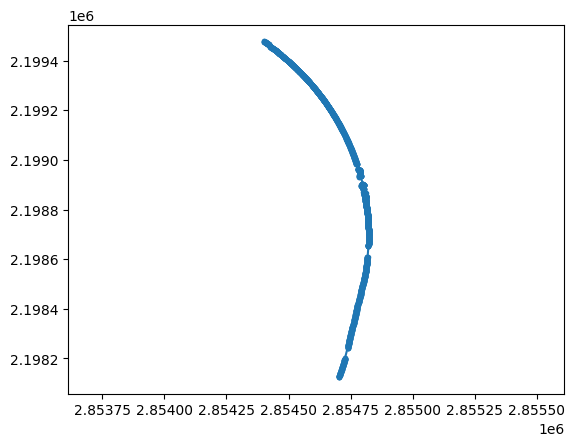

In [11]:
data = np.load(r"\\10.3.3.100\d\temp\Для Андрея\Для плана по обзорным камерам\dc_x_y_z.npy")
st, en = np.searchsorted(data[:, 0], [9618.434, 011241.841])
plt.plot(data[st:en, 1], data[st:en, 2], marker='.')
plt.axis('equal')

(np.float64(2839625.2200178425),
 np.float64(2855596.0697558615),
 np.float64(2184891.017169716),
 np.float64(2203601.170179997))

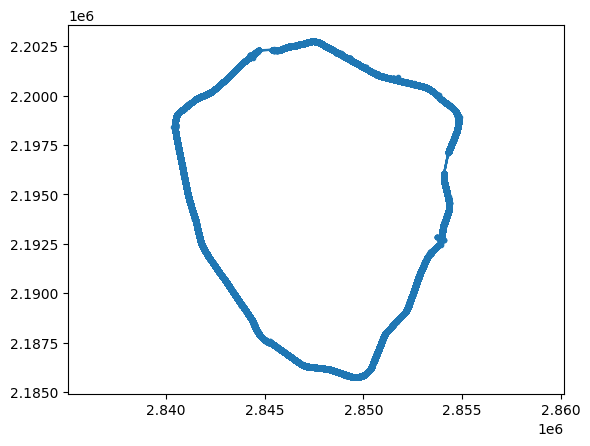

In [894]:
plt.plot(data[:, 1], data[:, 2], marker='.')
plt.axis('equal')

0


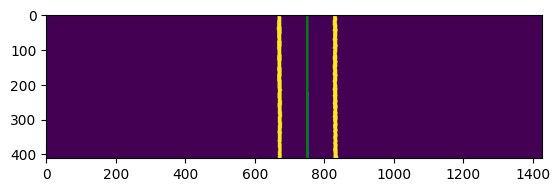

1


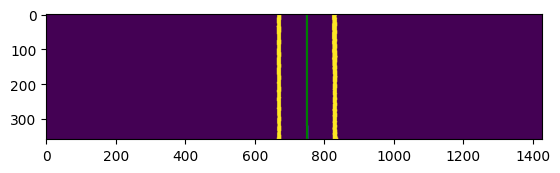

2


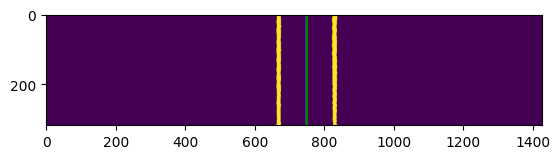

3


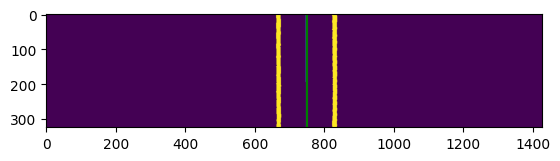

4


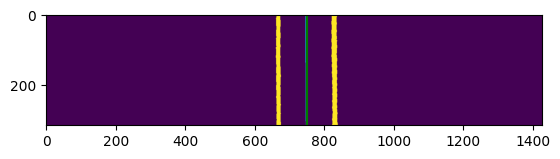

5


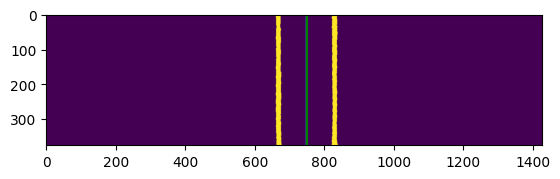

6


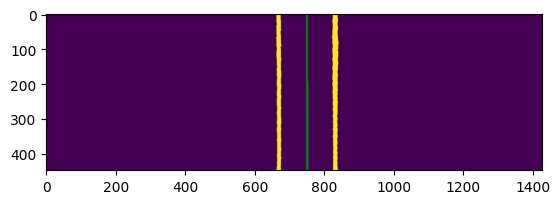

7


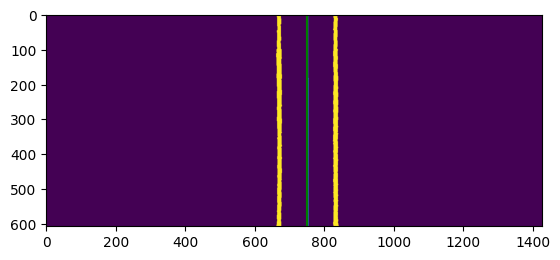

8


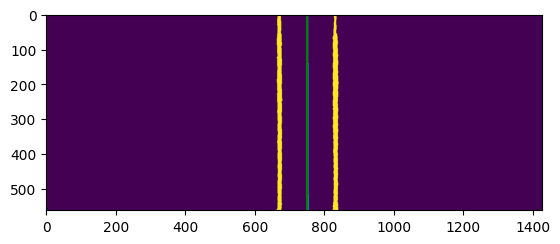

9


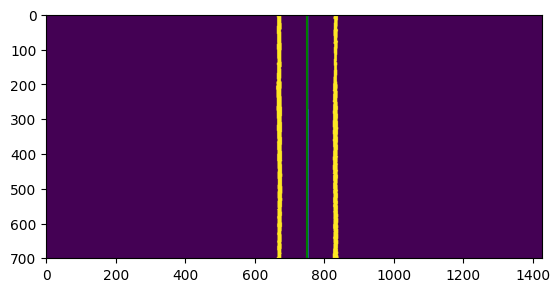

10


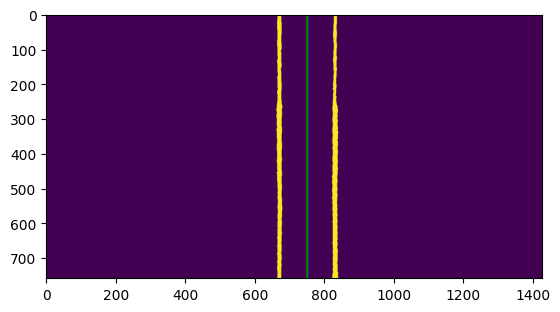

11


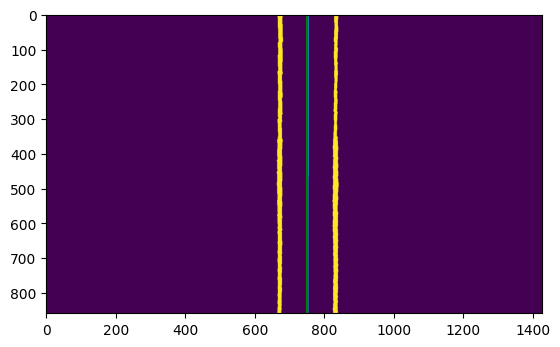

12


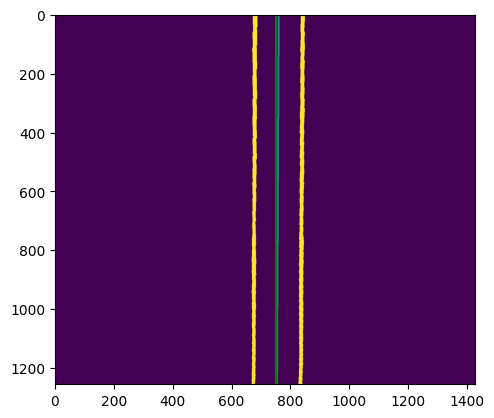

13


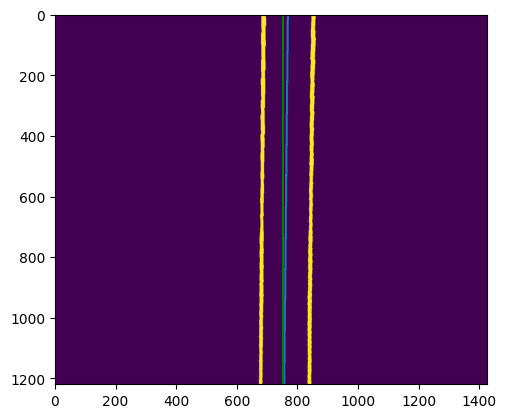

14


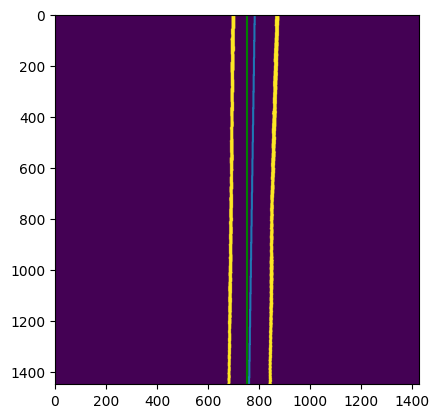

15


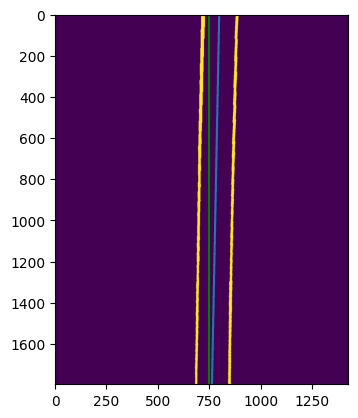

16


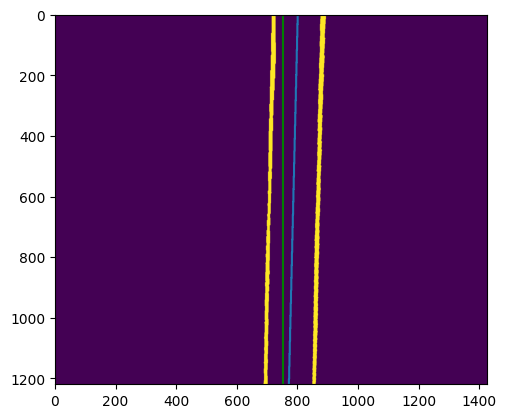

17


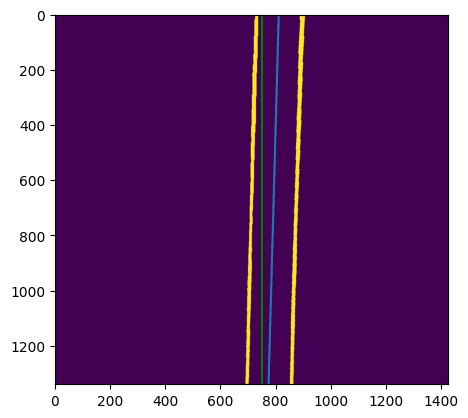

18


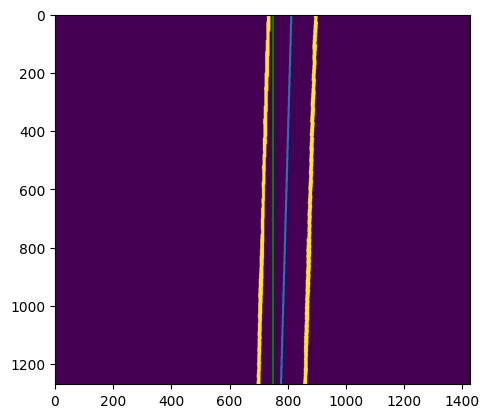

19


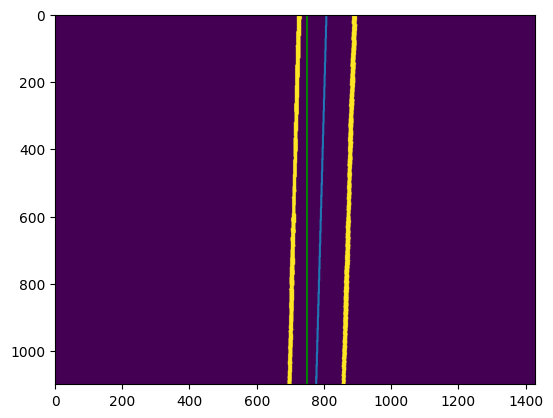

20


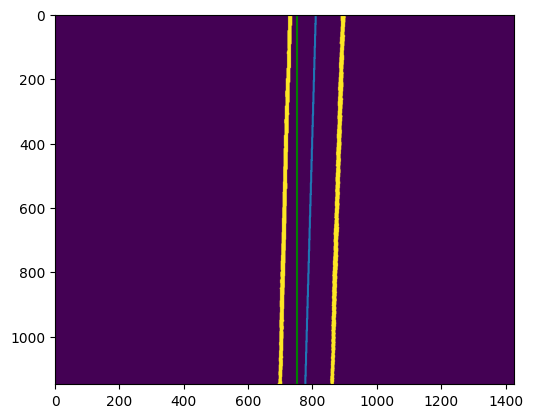

21


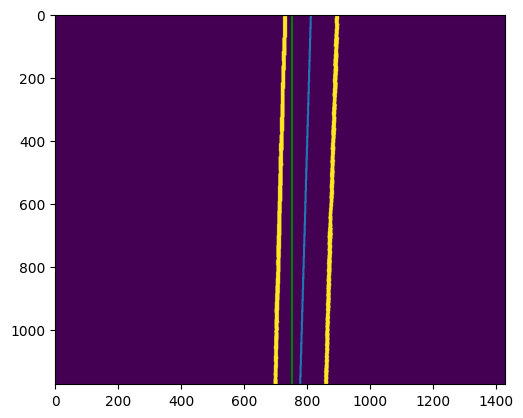

22


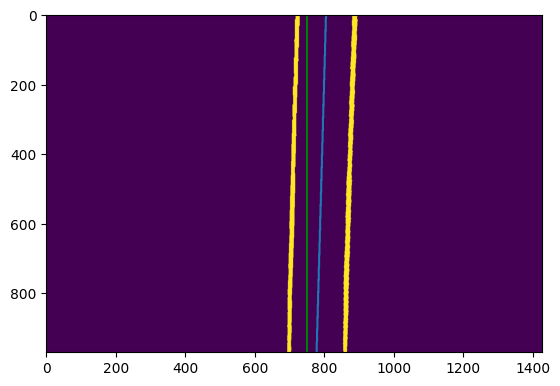

23


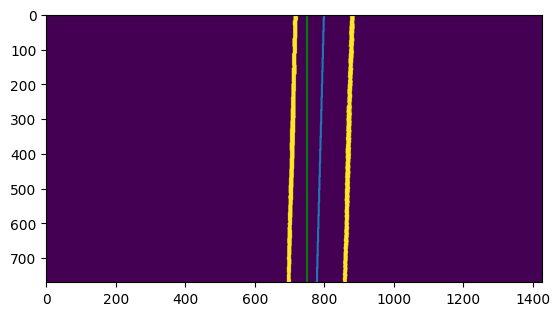

24


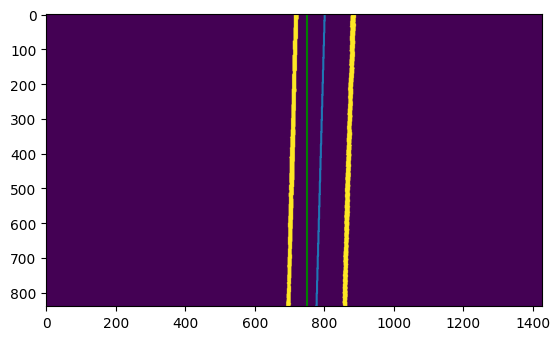

25


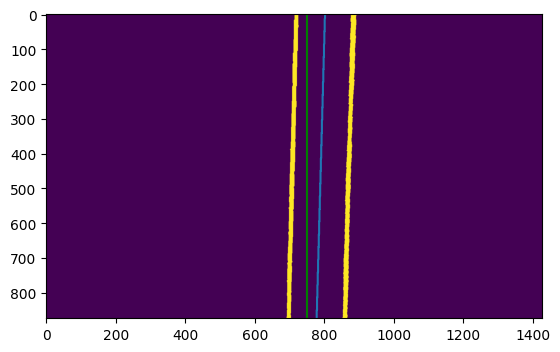

26


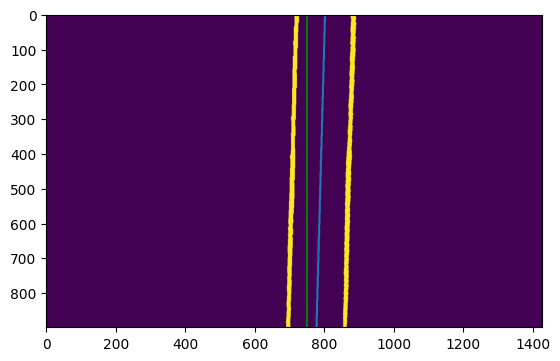

27


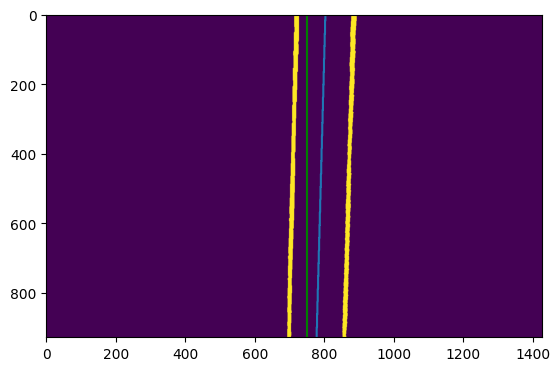

28


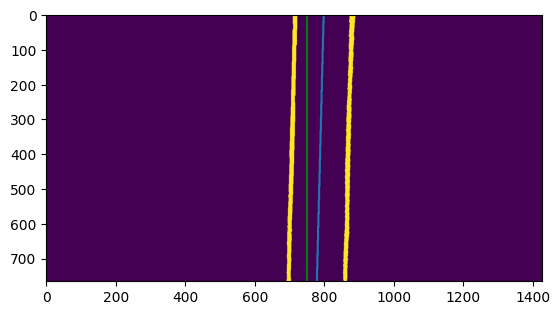

29


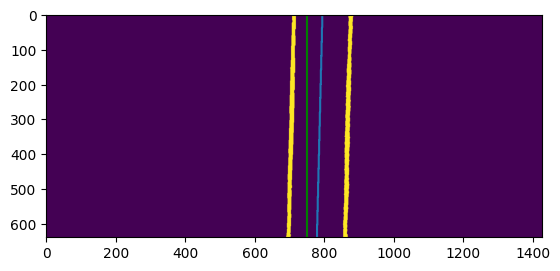

30


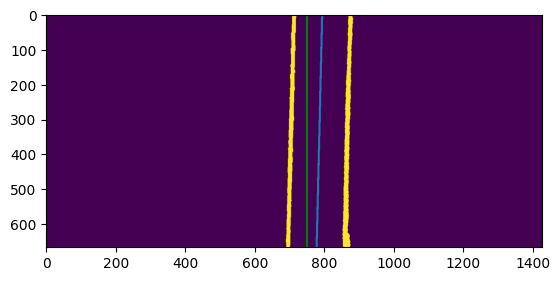

31


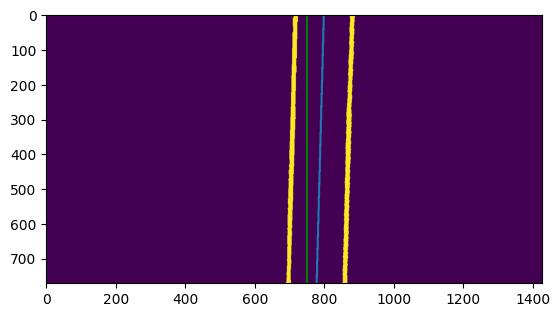

32


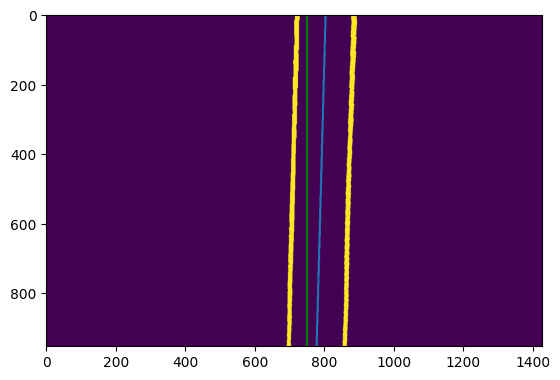

33


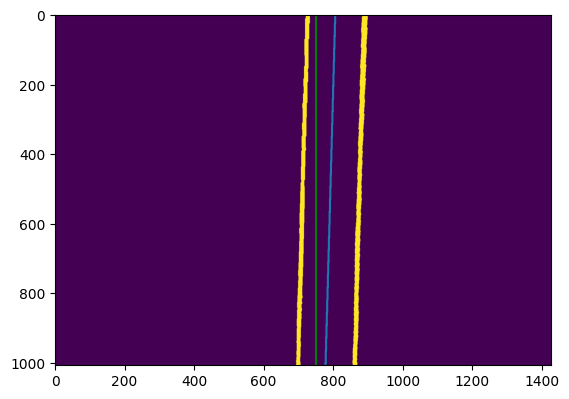

34


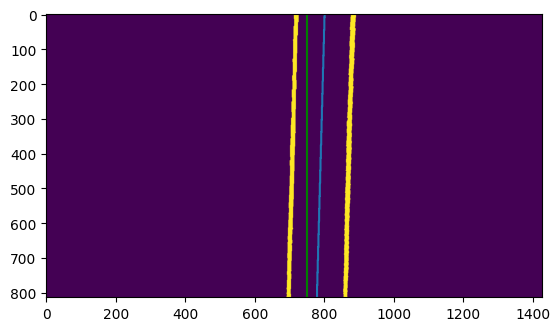

35


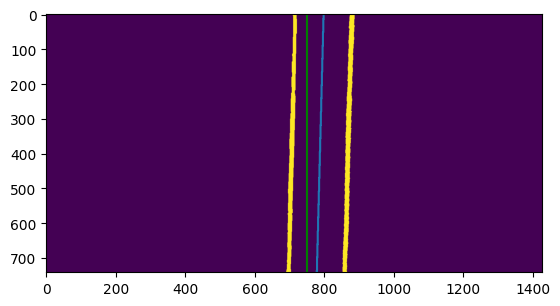

36


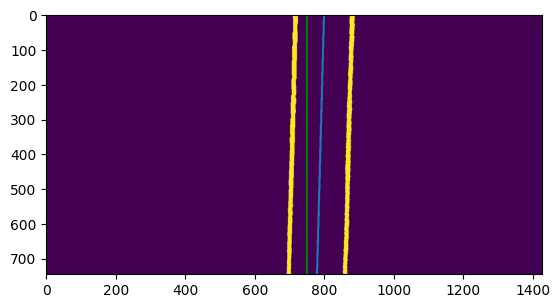

37


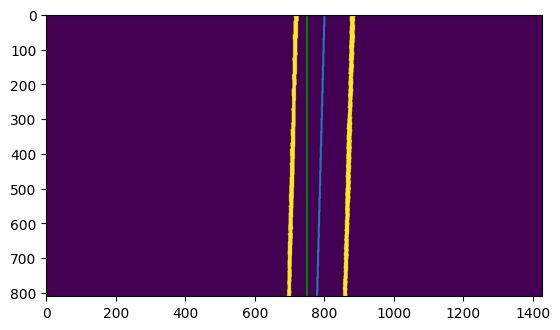

38


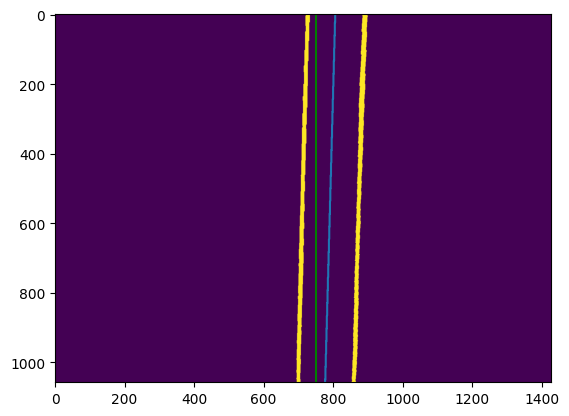

39


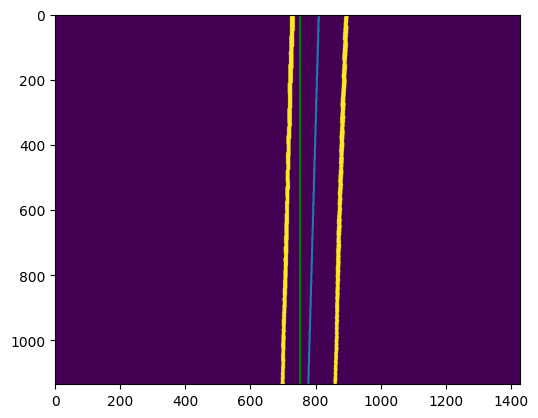

40


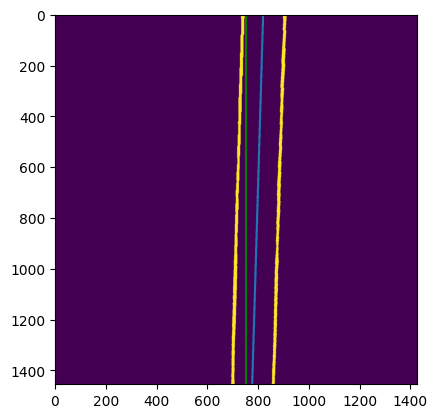

41


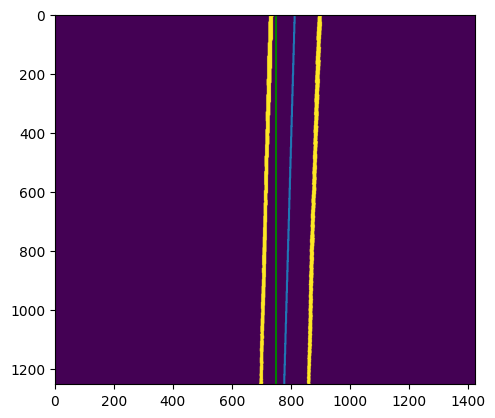

42


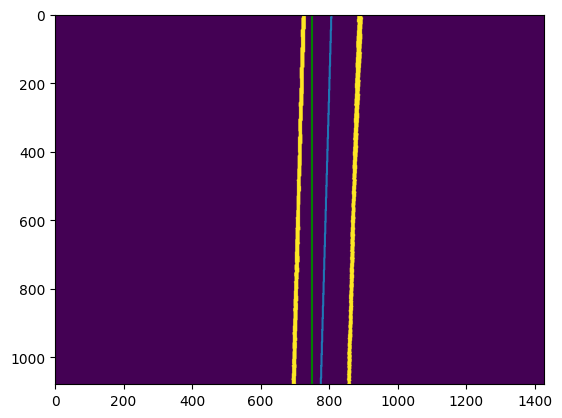

43


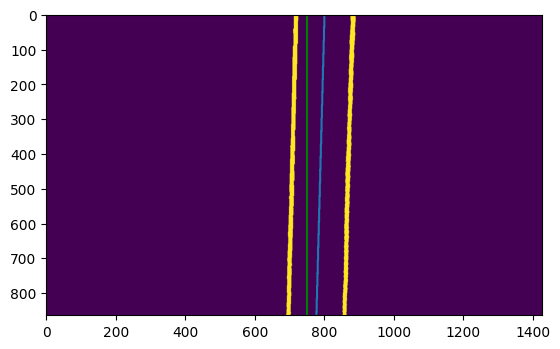

44


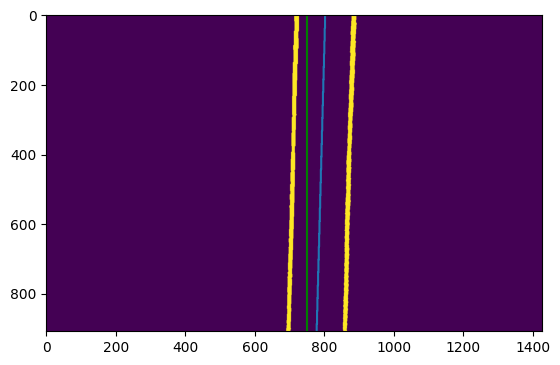

45


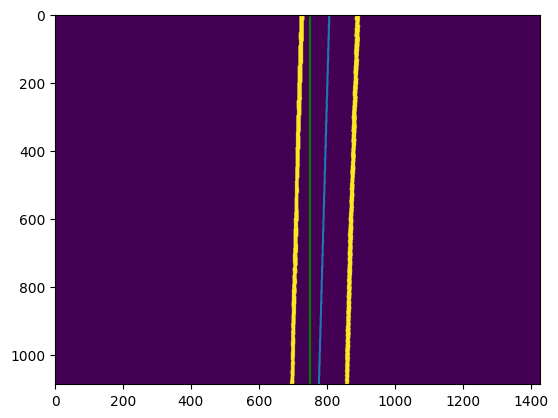

46


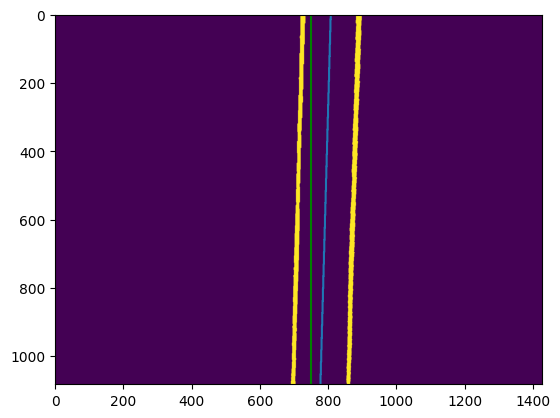

47


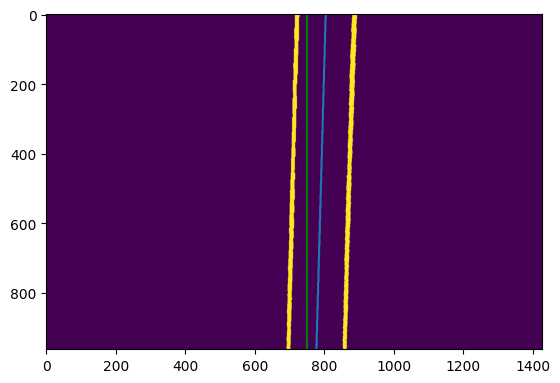

48


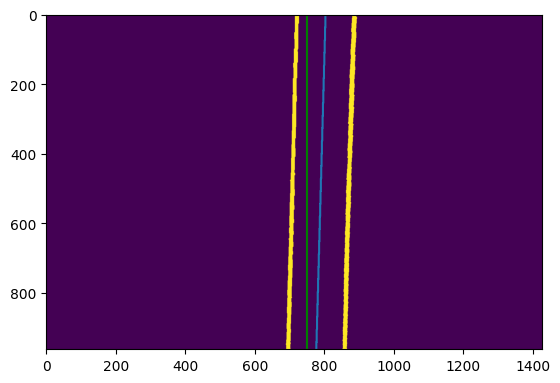

49


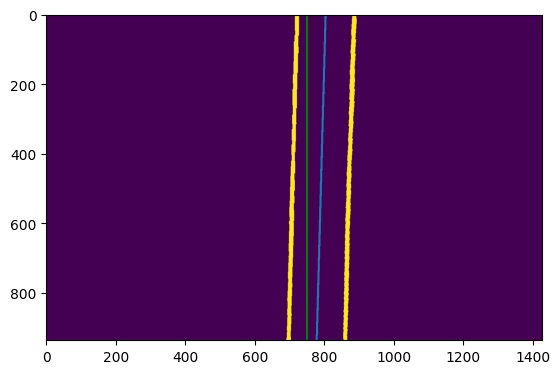

50


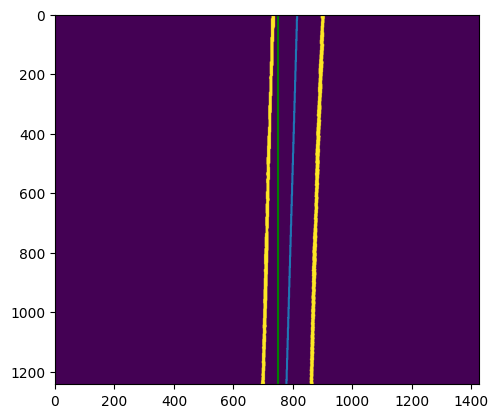

51


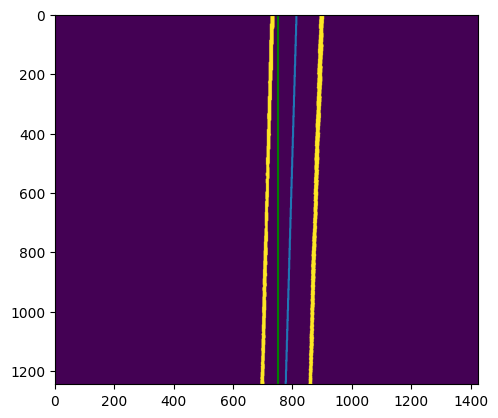

52


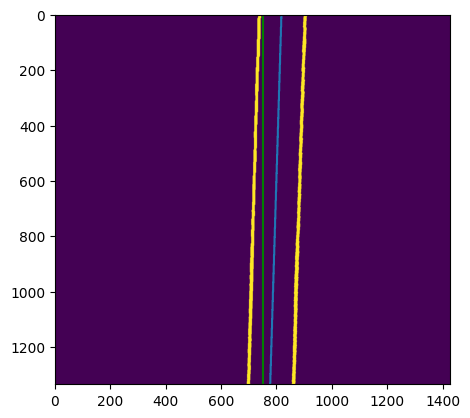

53


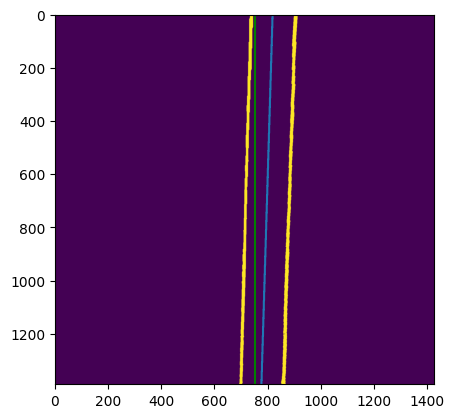

54


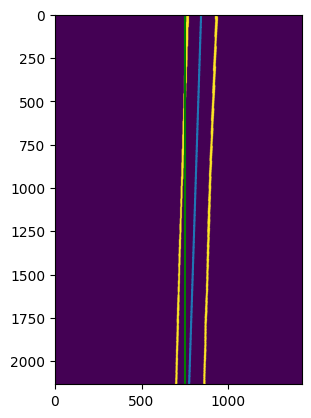

55


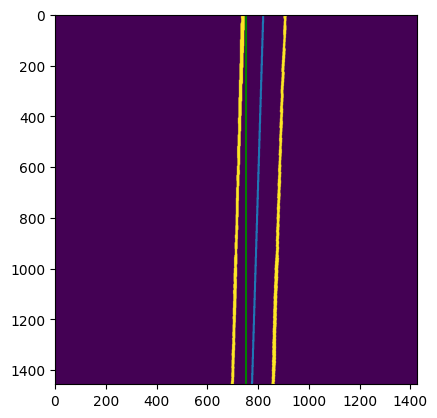

56


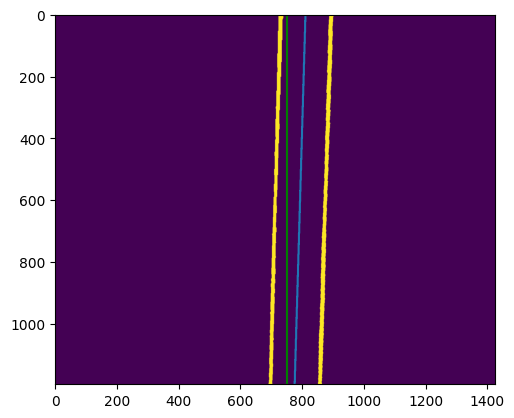

57


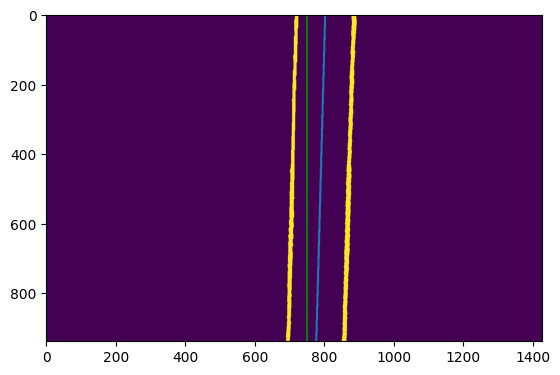

58


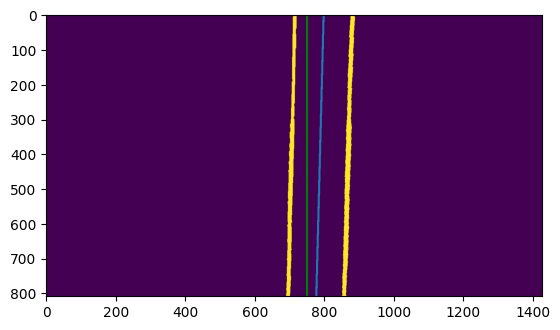

59


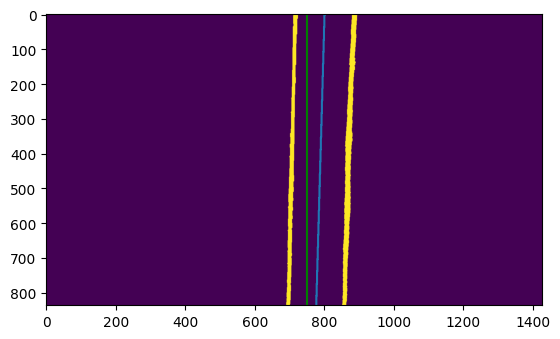

60


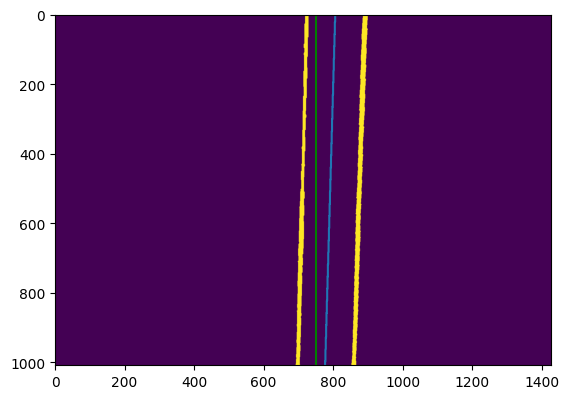

61


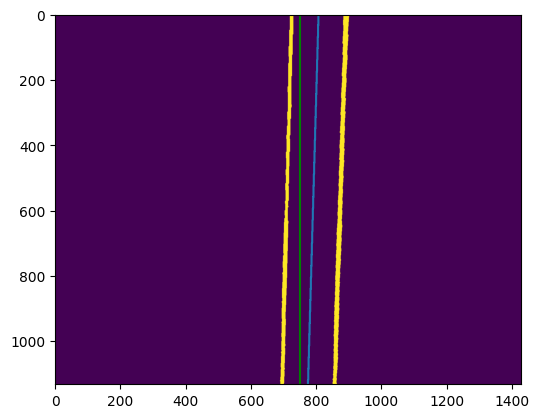

62


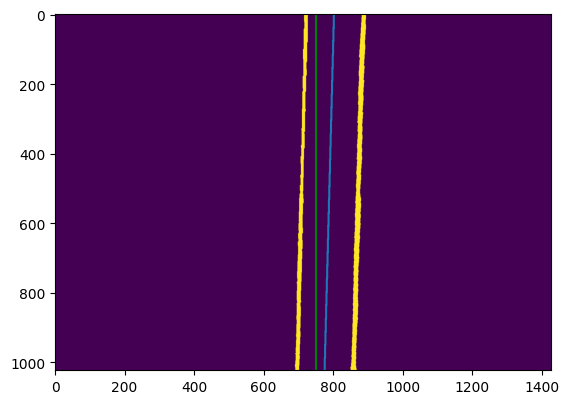

63


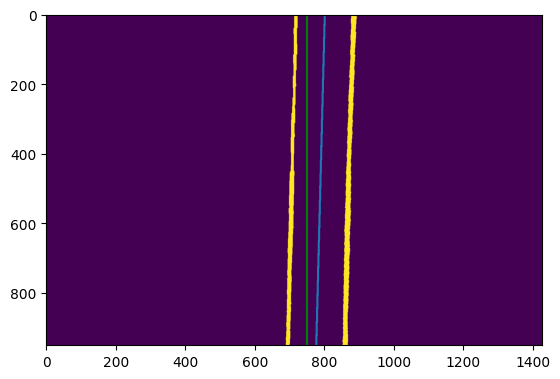

64


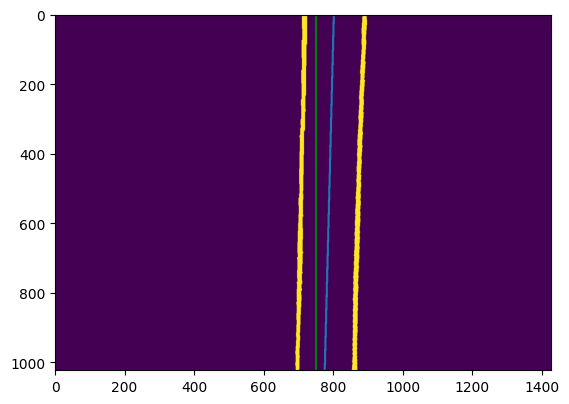

65


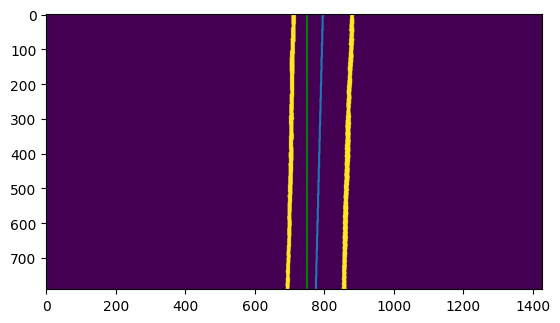

66


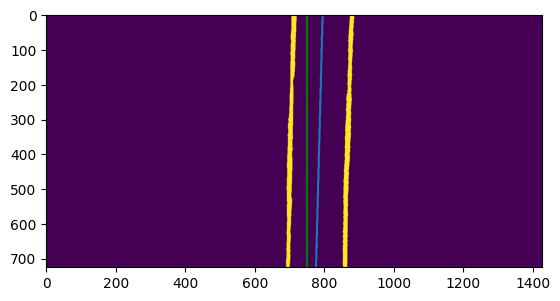

67


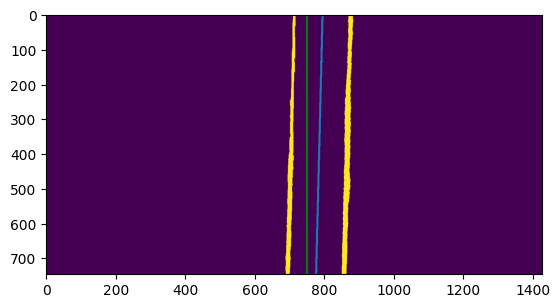

68


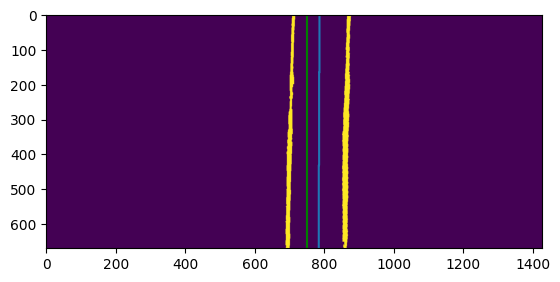

69


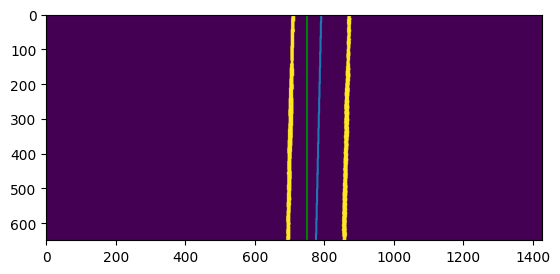

70


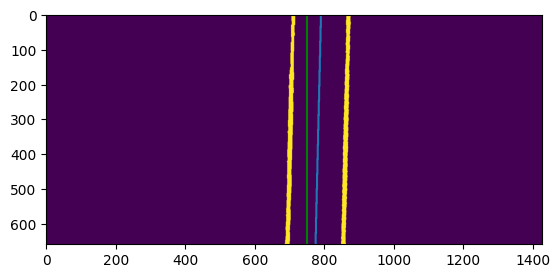

71


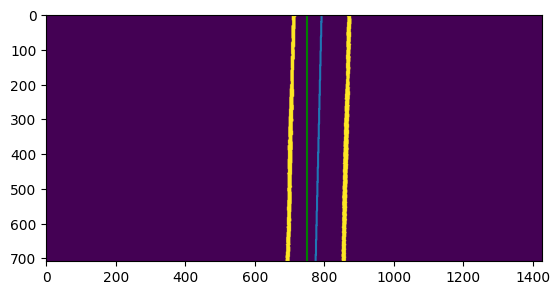

72


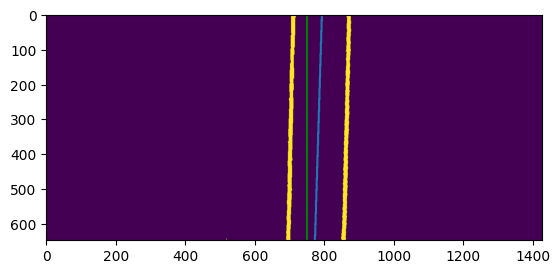

73


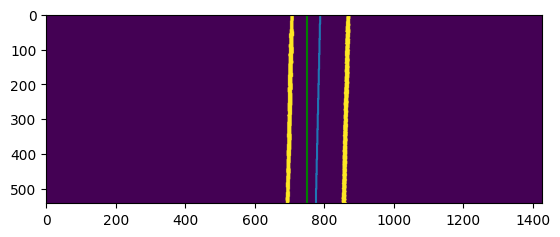

74


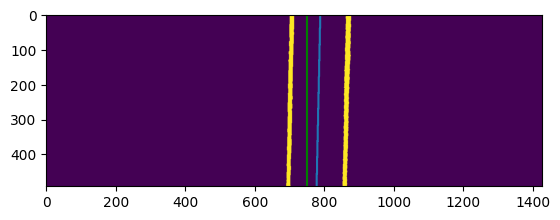

75


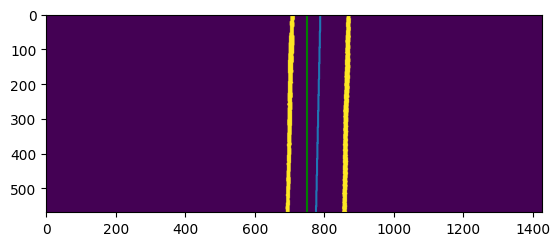

76


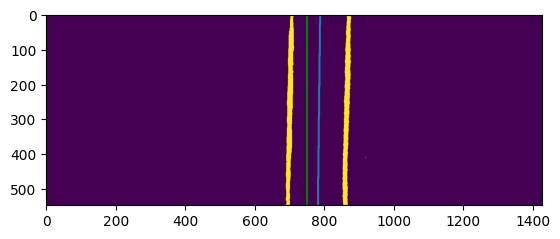

77


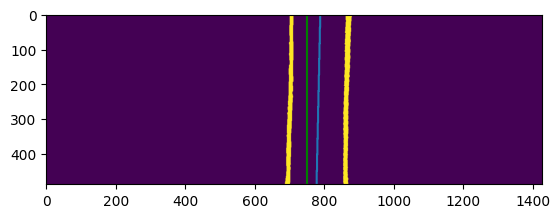

78


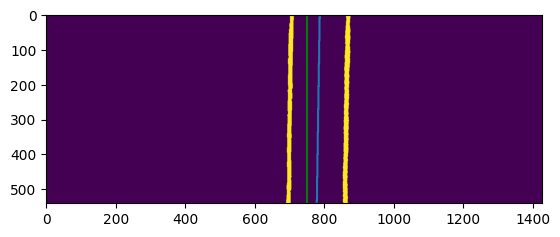

79


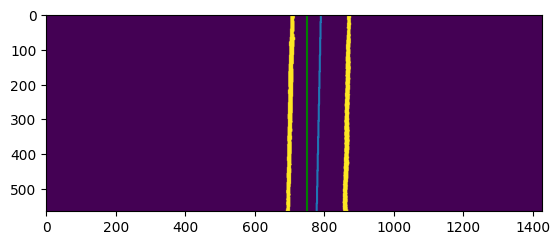

80


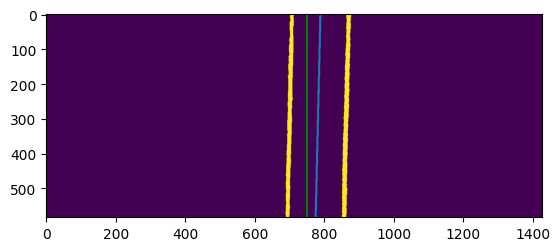

81


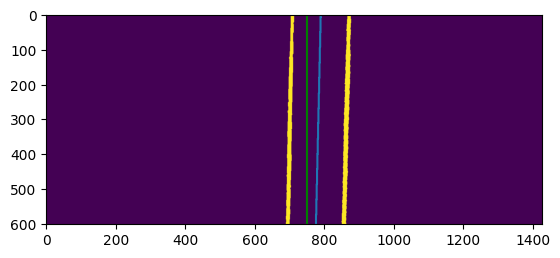

82


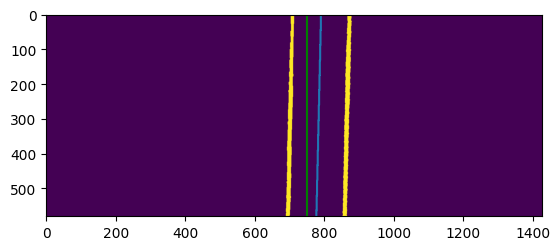

83


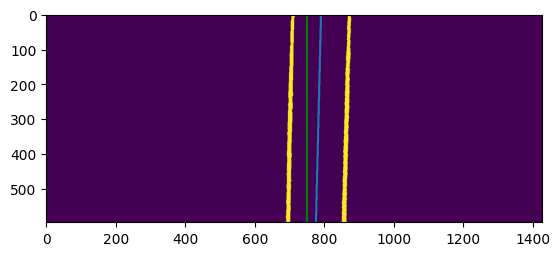

84


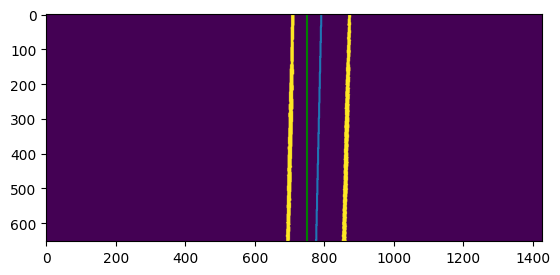

85


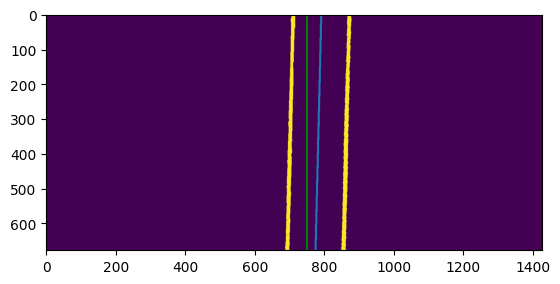

86


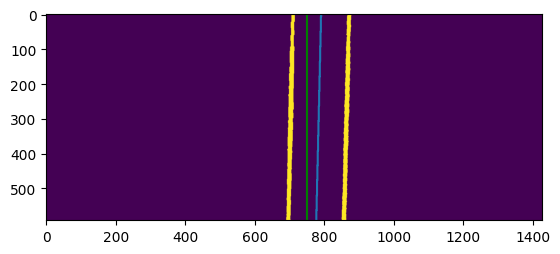

87


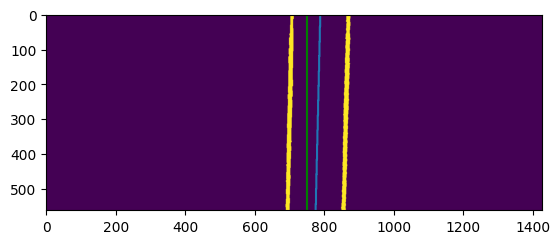

88


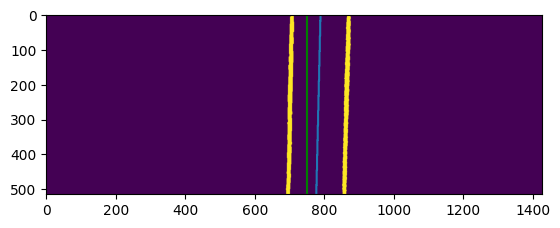

89


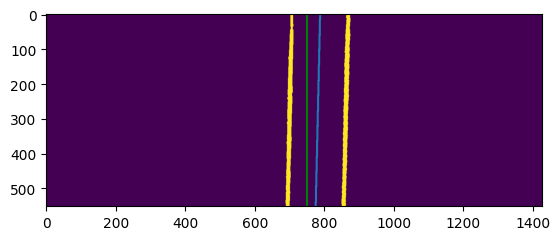

90


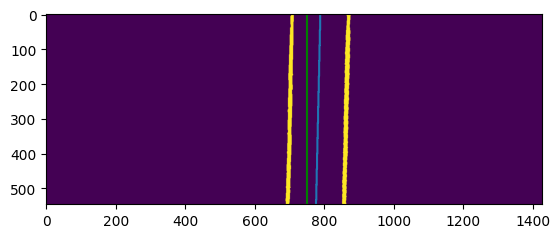

91


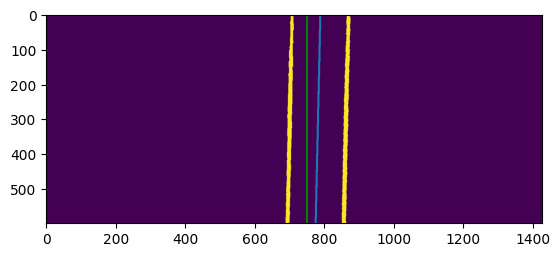

92


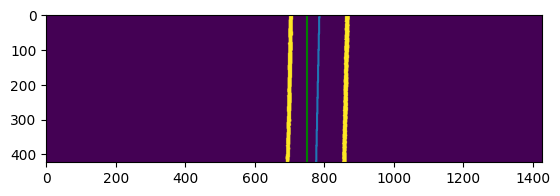

93


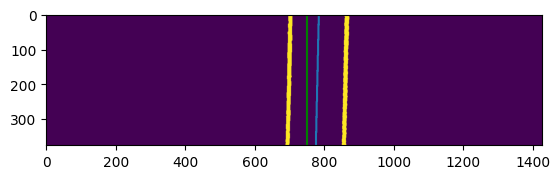

94


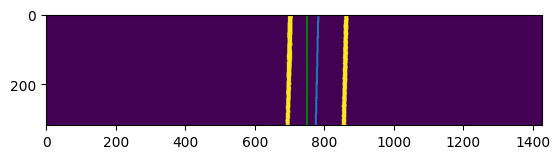

95


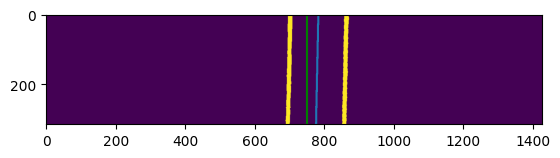

96


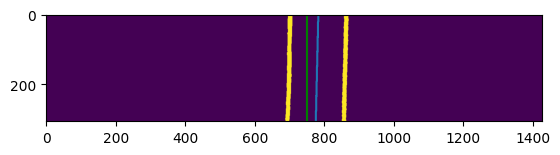

97


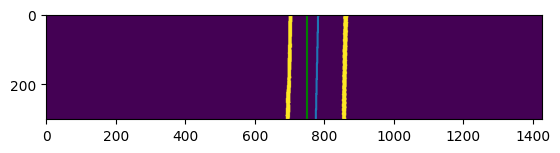

98


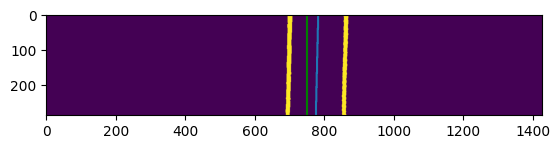

99


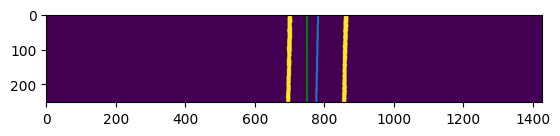

100


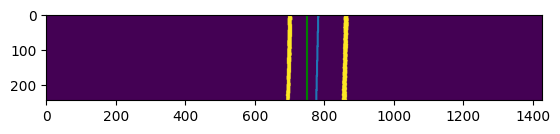

101


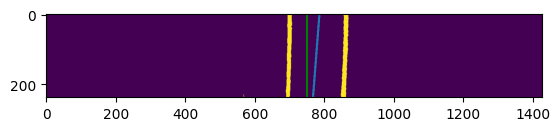

102


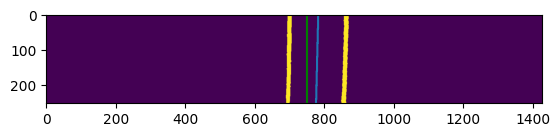

103


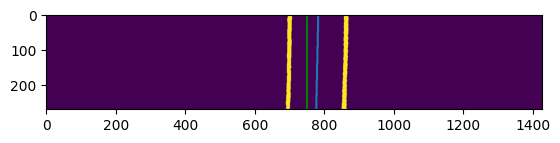

104


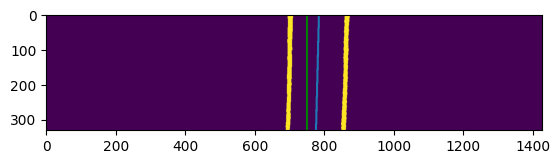

105


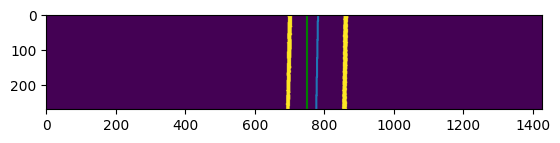

106


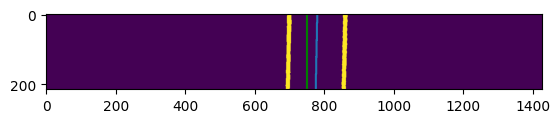

107


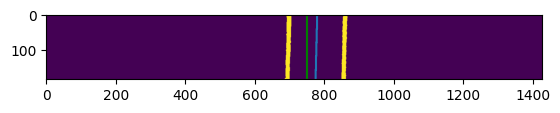

108


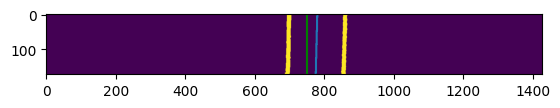

109


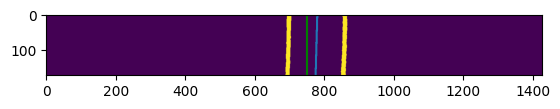

110


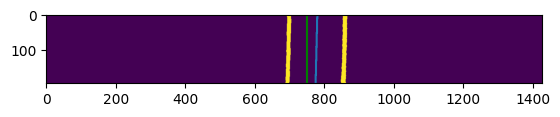

111


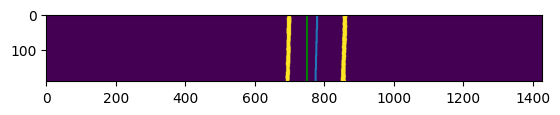

112


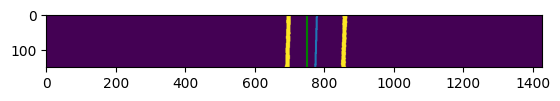

113


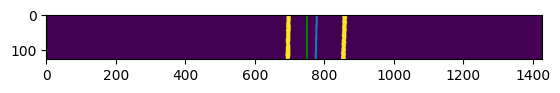

114


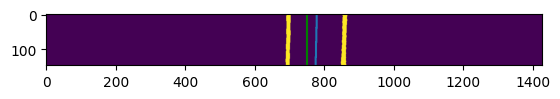

115


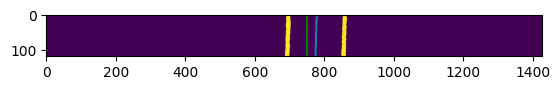

116


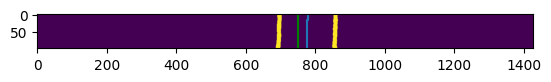

117


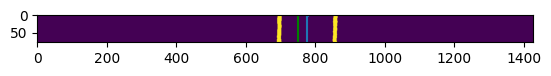

118


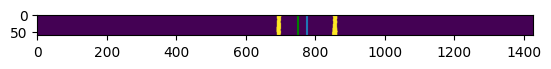

119


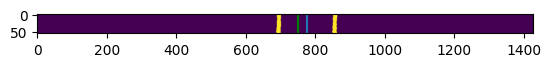

120


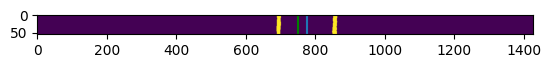

121


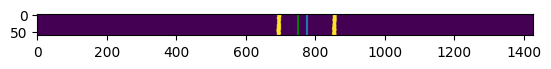

122


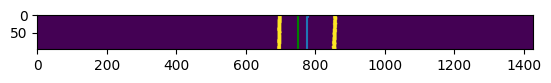

123


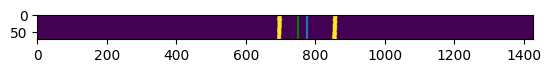

124


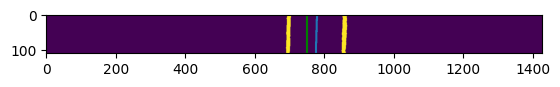

125


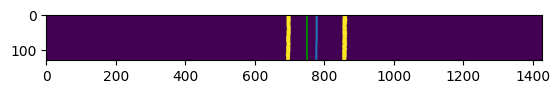

126


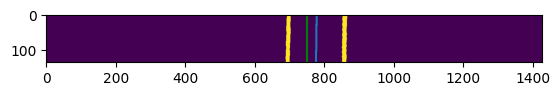

127


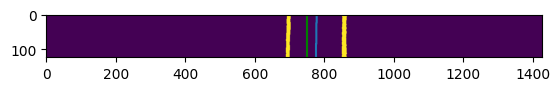

128


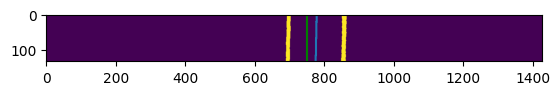

129


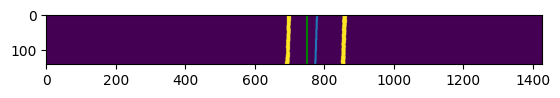

130


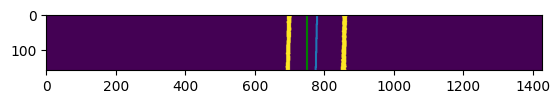

131


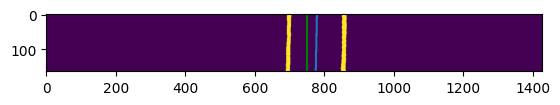

132


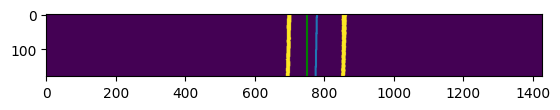

133


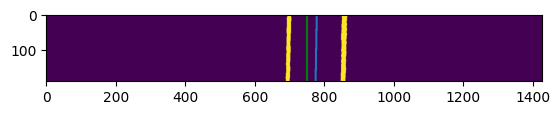

134


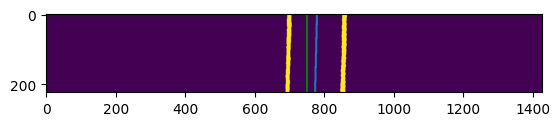

135


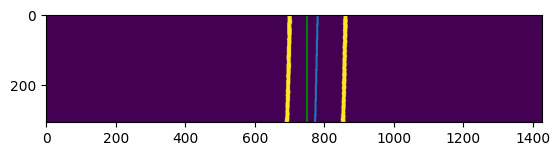

136


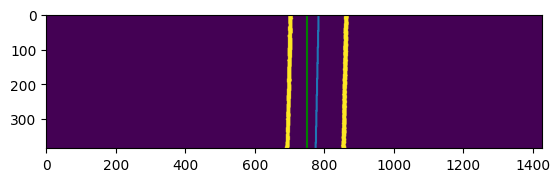

137


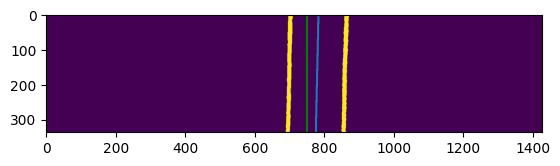

138


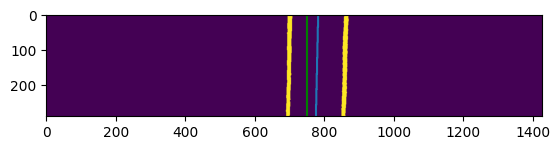

139


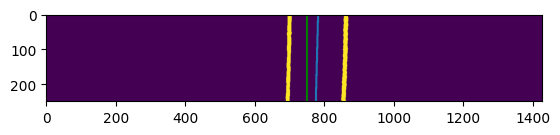

140


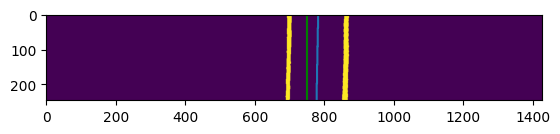

141


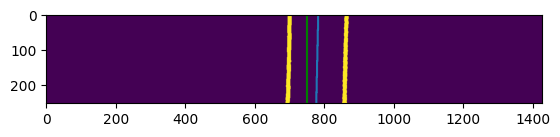

142


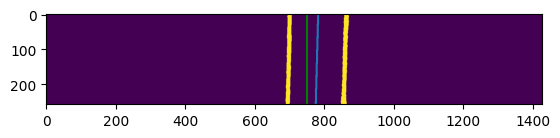

143


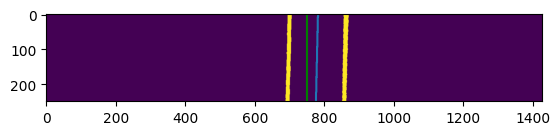

144


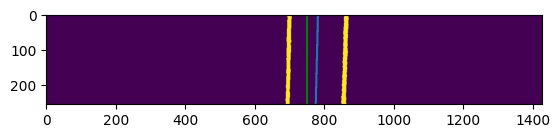

145


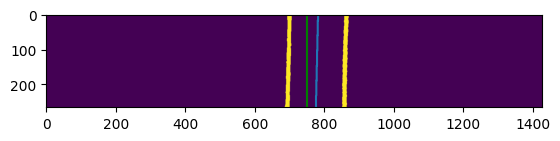

146


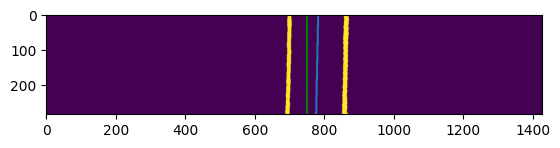

147


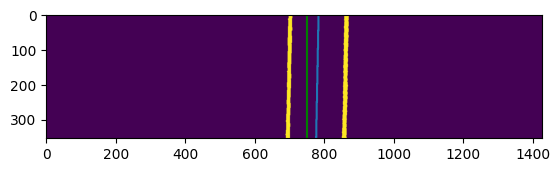

148


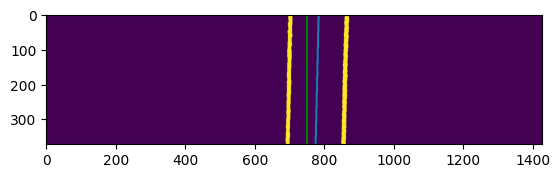

149


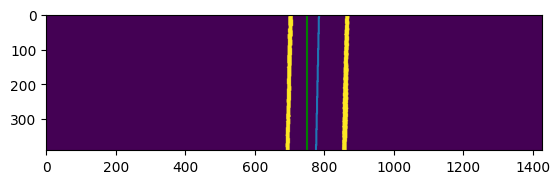

150


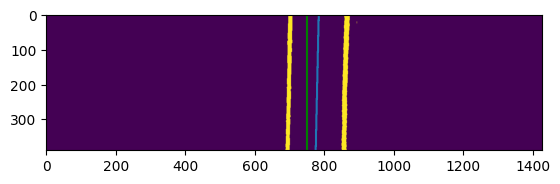

151


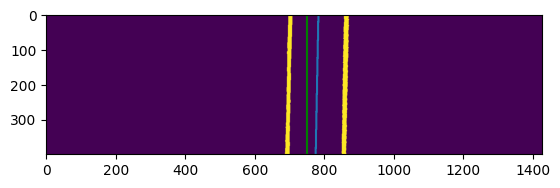

152


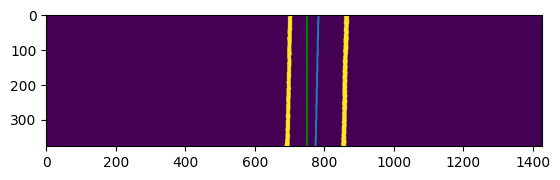

153


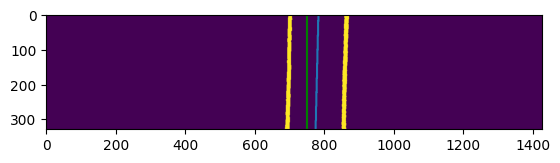

154


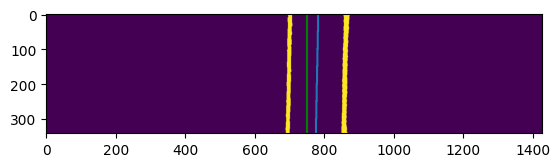

155


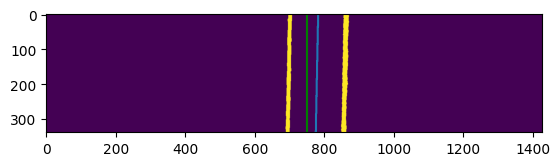

156


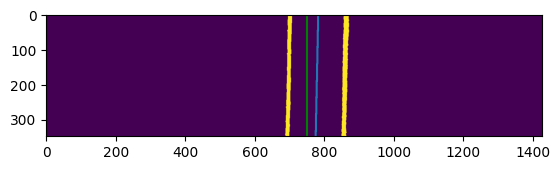

157


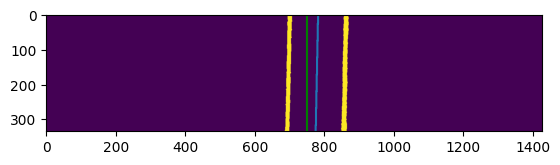

158


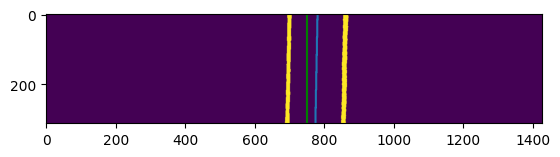

159


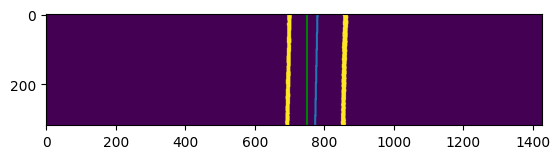

160


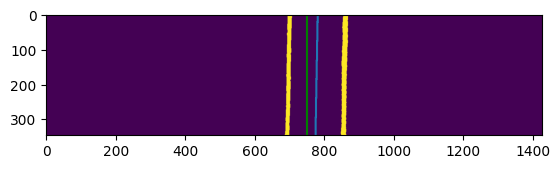

161


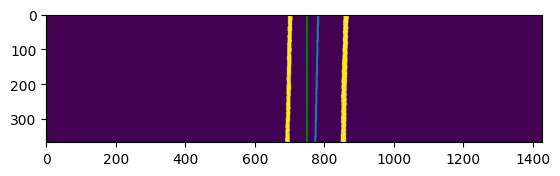

162


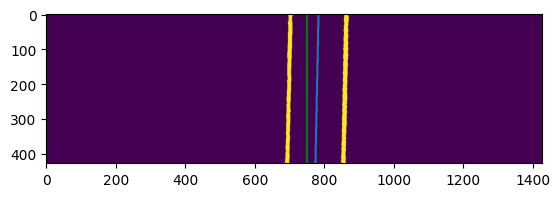

163


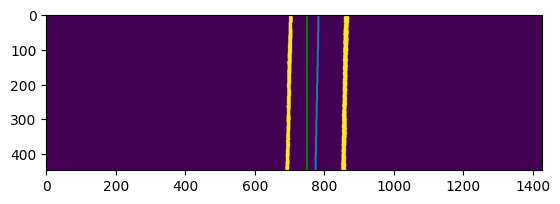

164


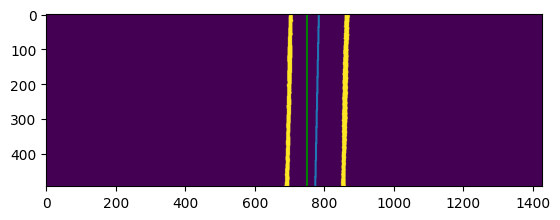

165


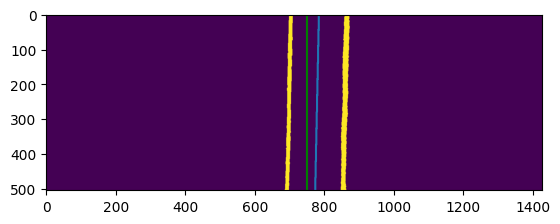

166


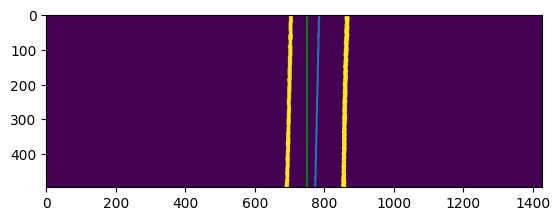

167


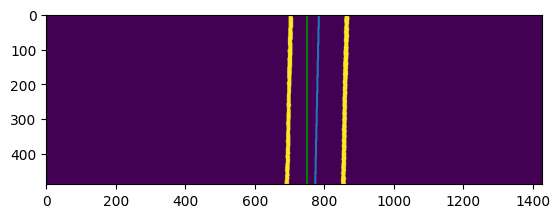

168


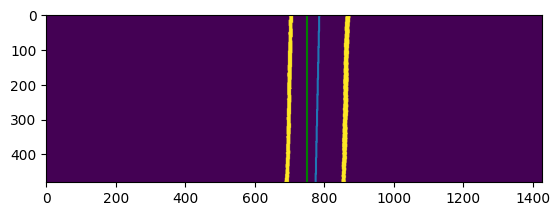

169


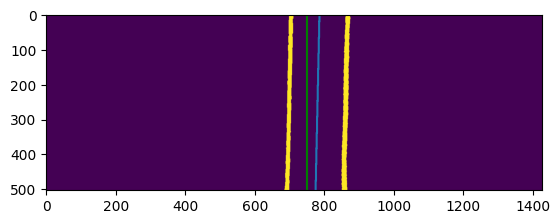

170


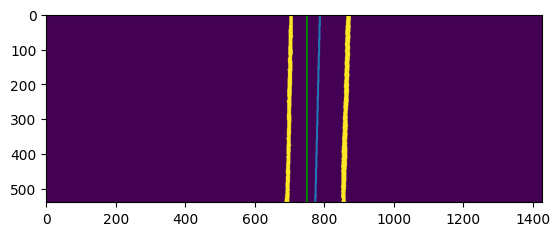

171


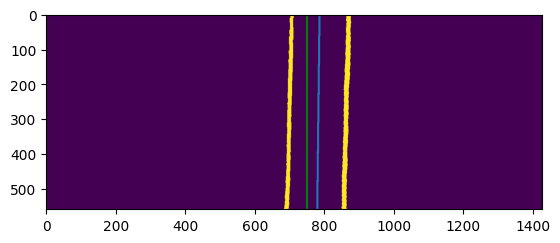

172


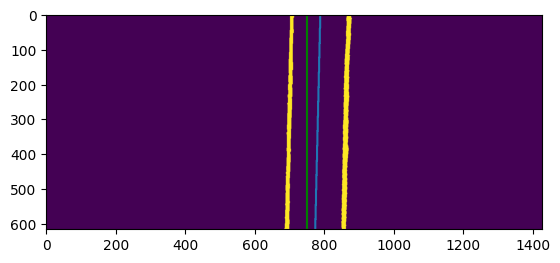

173


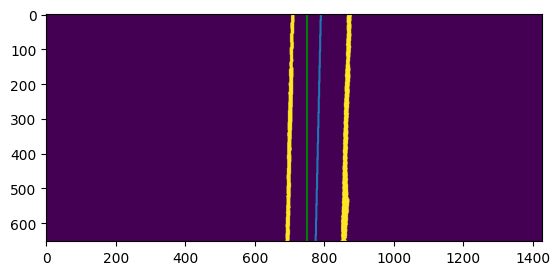

174


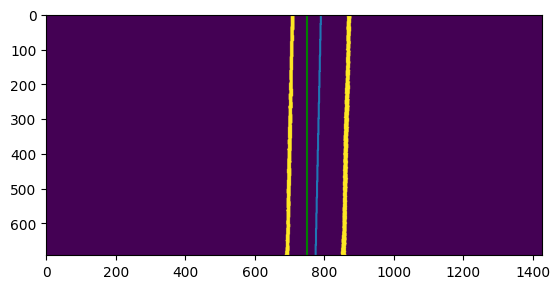

175


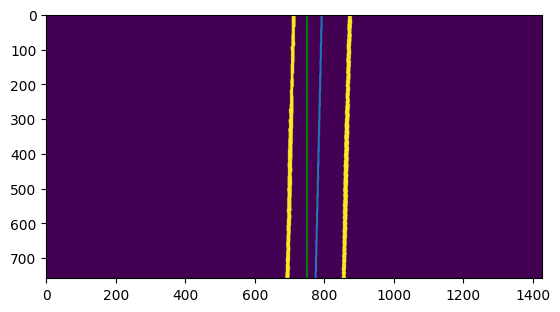

176


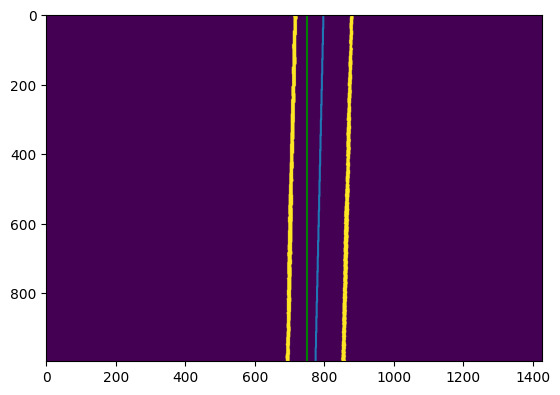

177


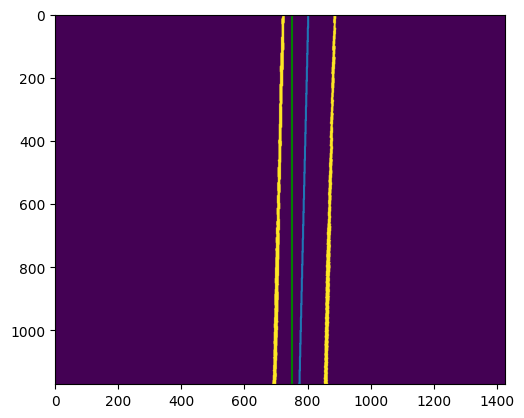

178


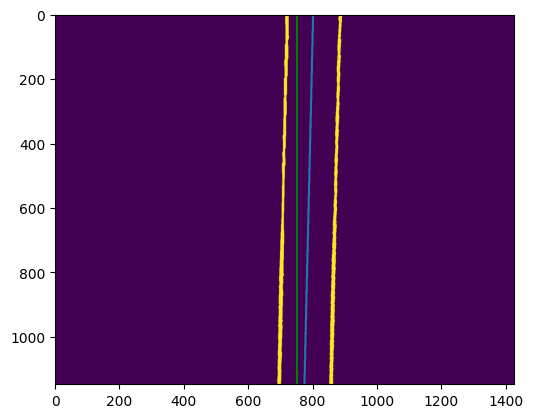

179


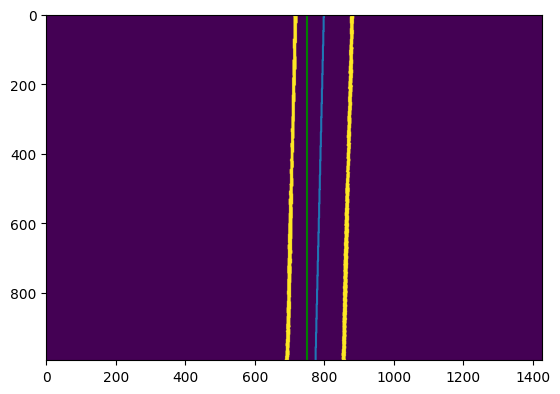

180


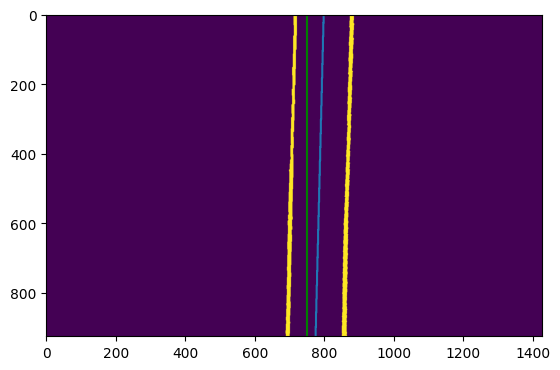

181


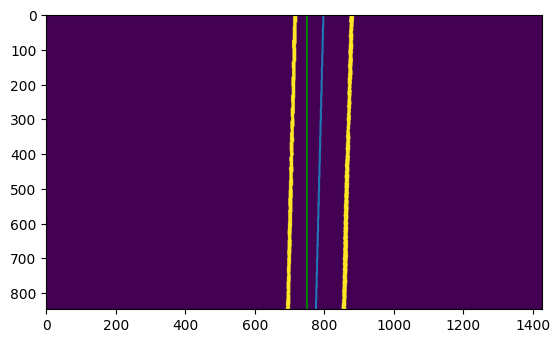

182


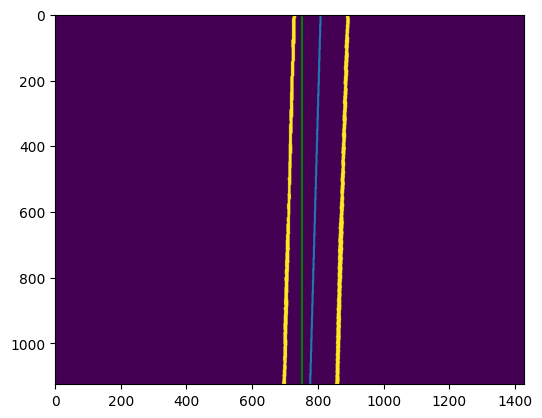

183


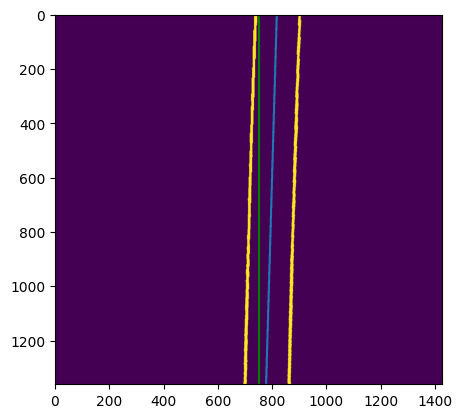

184


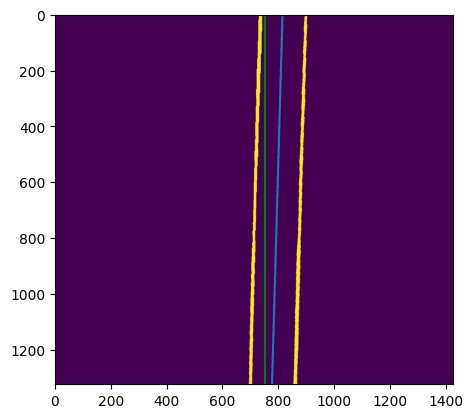

185


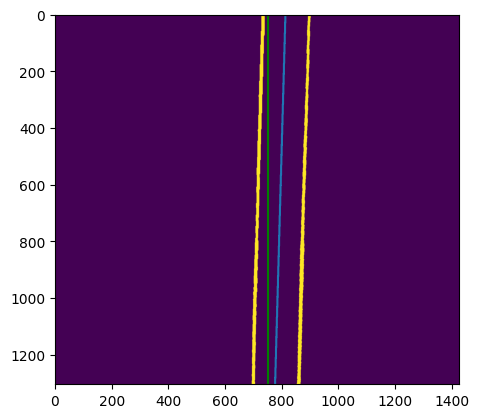

186


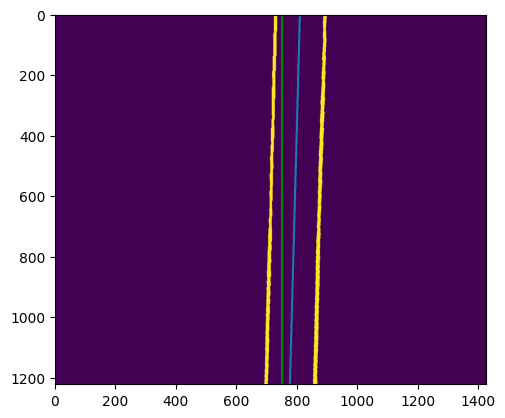

187


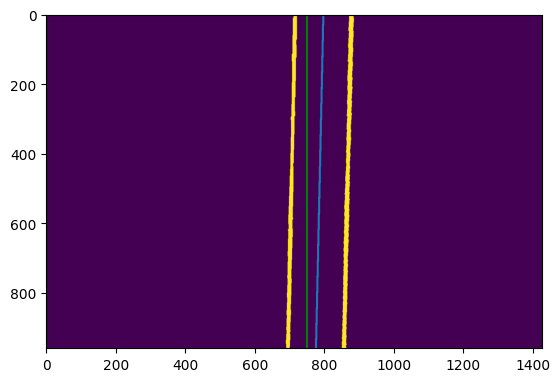

188


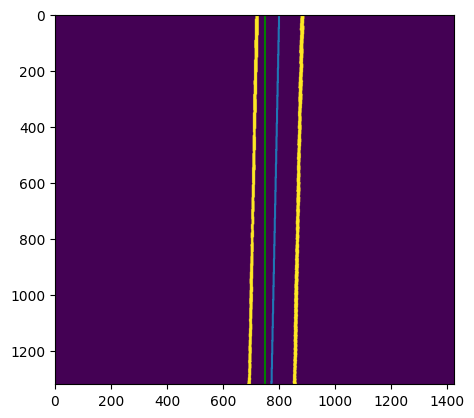

189


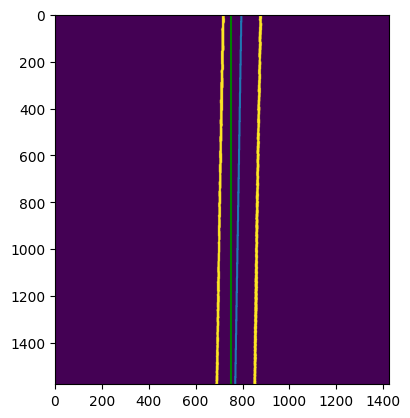

190


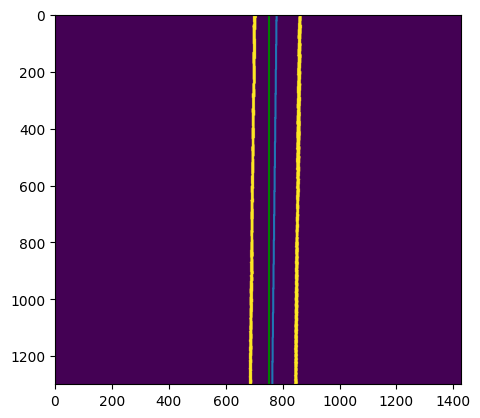

191


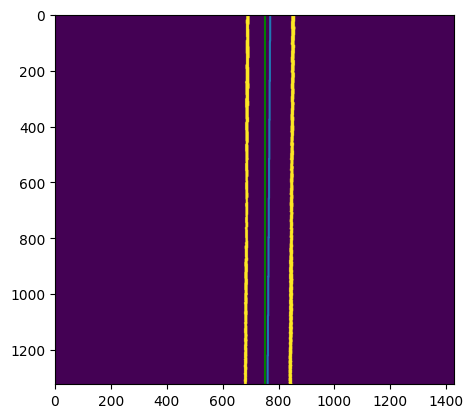

192


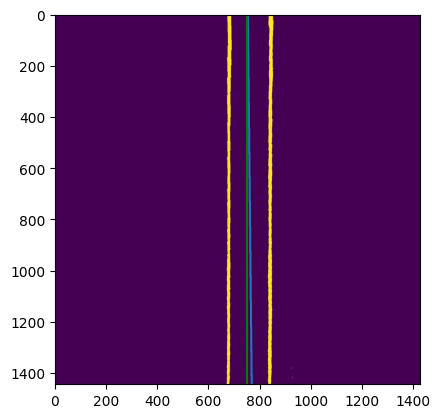

193


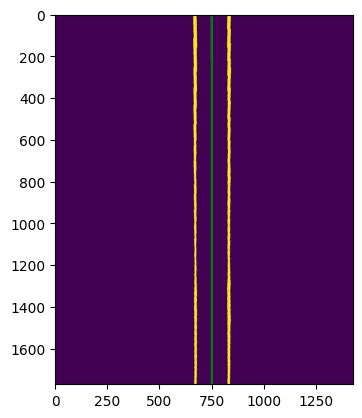

194


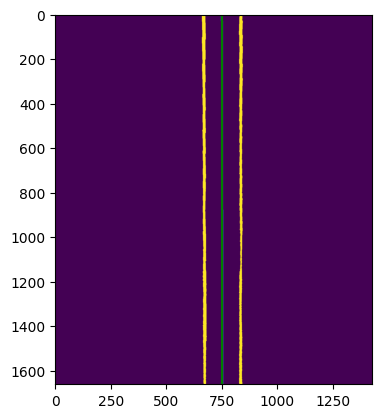

195


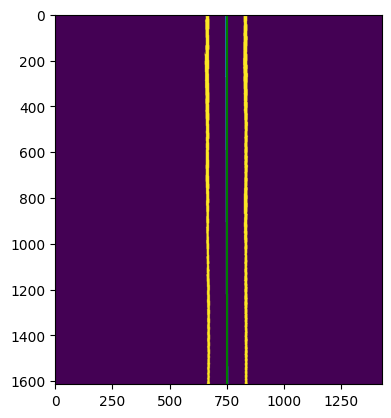

196


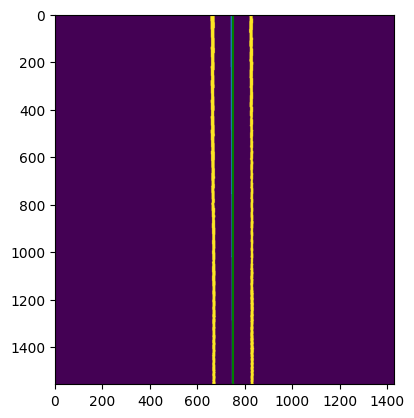

197


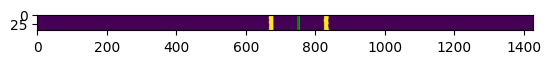

198


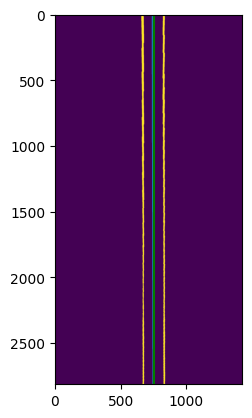

199


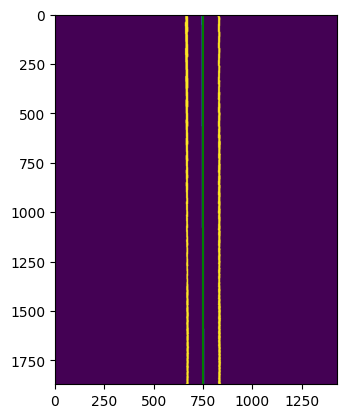

200


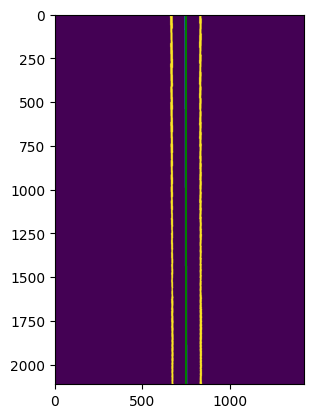

201


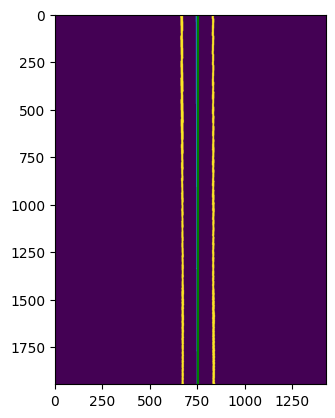

202


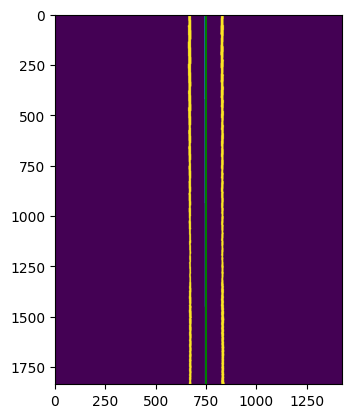

203


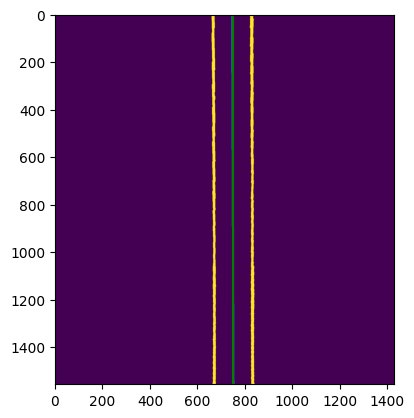

204


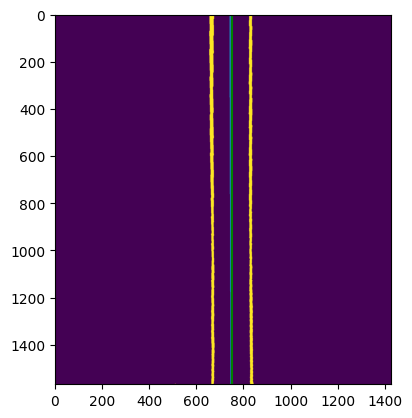

205


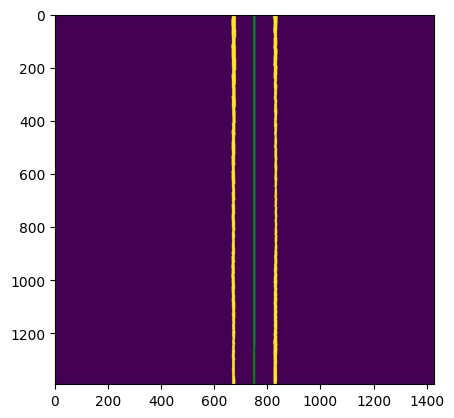

206


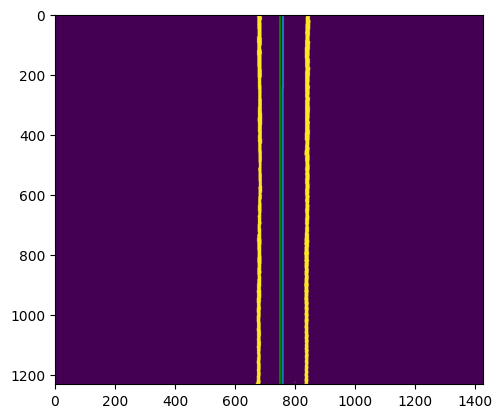

207


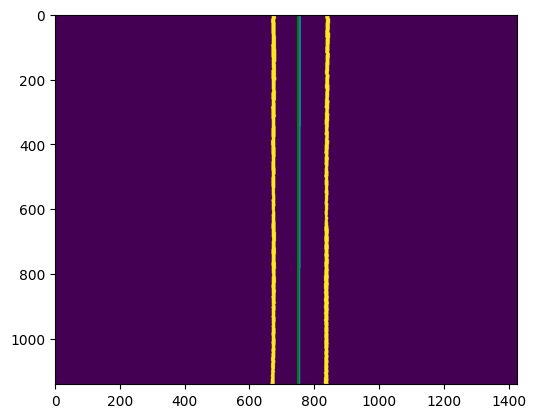

208


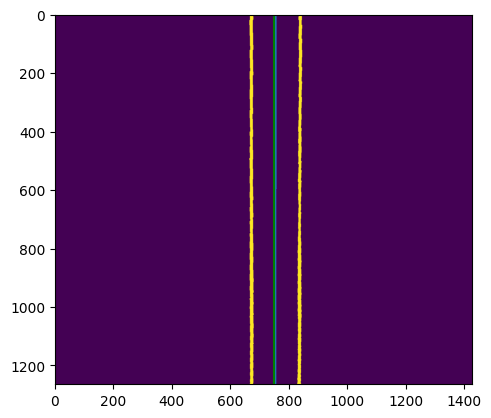

209


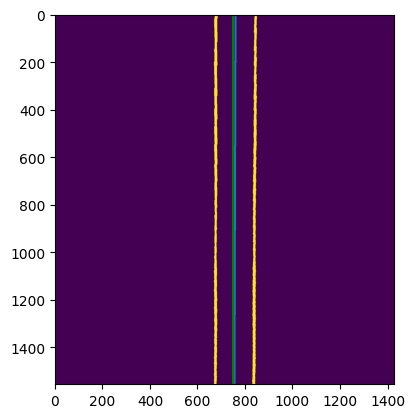

210


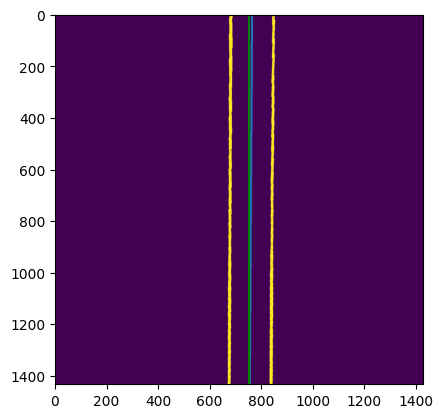

211


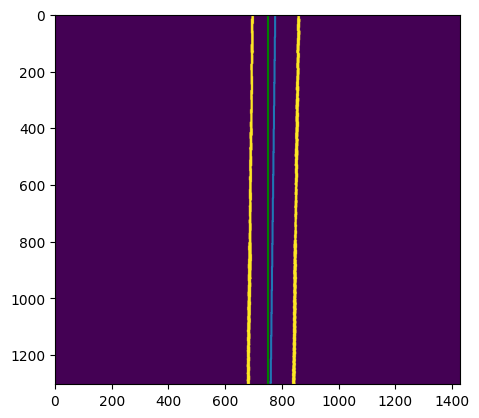

212


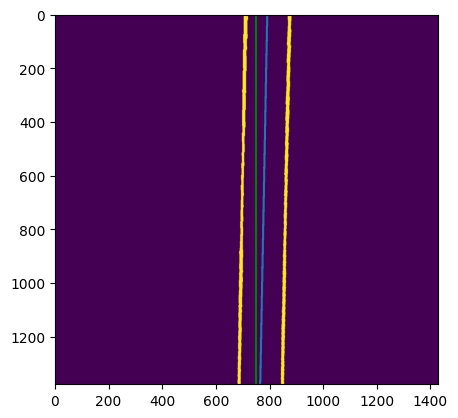

213


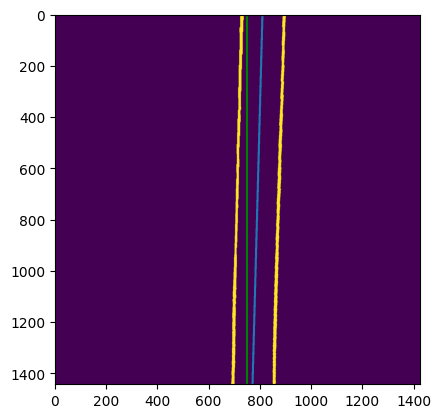

214


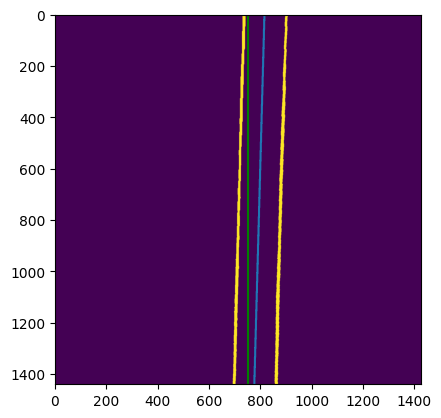

215


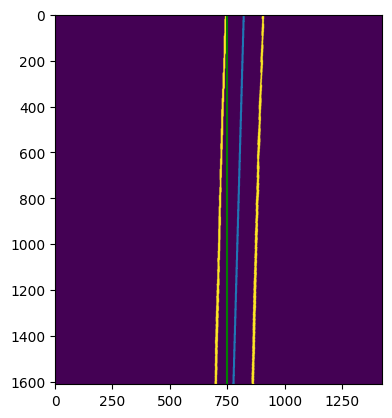

In [19]:
# проверить маски

for i, (m_f, c) in enumerate(zip(msk_fs[0:-1], coord[0:-1])):  # 0:-1 0:2 13:14 20:22 20:32 29:32
    mask = load_warp(m_f)
    mask = mask[mask.shape[0]-(coord[i+1] - coord[i]): mask.shape[0]+1]  # низ маски. низ - текущ коорд, верх след коорд (включительно)

    # mask = bend(mask, shift=2000)  # !! для теста
    _, yx_centr = find_rail_dots(mask, step=200)

    # преобразовать ось Y (переворот). Т.к.координаты на маске от нуля вверху,
    # реальные - от нуля внизу, и едем вперед
    yx_centr = yx_centr.T
    _y = yx_centr[:, 0]
    _y = _y[::-1]
    yx_centr[:, 0] = _y
    # ===========================================

    # ===========================================
    # лин регрессия
    kb = np.polyfit(yx_centr[:, 0], yx_centr[:, 1], 1)
    f = np.poly1d(kb)
    y_n = np.arange(yx_centr.shape[0])
    x_lin = f(yx_centr[:, 0])
    yx_centr[:, 1] = x_lin
    # ===========================================
    print(i)
    plt.imshow(resize(mask))
    plt.plot(yx_centr[:, 1]//10, yx_centr[:, 0][::-1]//10)
    plt.axvline((mask.shape[1] // 20)+38, c='g')
    plt.margins(0, 0)
    plt.show()

In [4]:
data = np.load(r"D:\Projects\perspective\data\4\data_4.npy")
data.shape

(216, 2, 2)

In [ ]:
# yx_centr низ [-1], верх [0]
# for i, (m_f, c) in enumerate(zip(msk_fs[0:-1], coord[0:-1])):  # 0:-1 0:2 13:14 20:22 20:32 29:32 80:90
#     # пройденный путь до след коорд
#     L = (coord[i+1] - coord[i])

#     mask = load_warp(m_f)
#     mask = mask[mask.shape[0]-L: mask.shape[0]+1]  # низ маски. низ - текущ коорд, верх след коорд (включительно)

#     # mask = bend(mask, shift=2000)  # !! для теста
#     _, yx_centr = find_rail_dots(mask, step=200)
#     # преобразовать ось Y (переворот). Т.к.координаты на маске от нуля вверху,
#     # реальные - от нуля внизу, и едем вперед
#     yx_centr = yx_centr.T
#     _y = yx_centr[:, 0]
#     _y = _y[::-1]
#     yx_centr[:, 0] = _y
#     # ===========================================
#     # лин регрессия
#     kb = np.polyfit(yx_centr[:, 0], yx_centr[:, 1], 1)
#     f = np.poly1d(kb)
#     y_n = np.arange(yx_centr.shape[0])
#     x_lin = f(yx_centr[:, 0])
#     yx_centr[:, 1] = x_lin
#     # ===========================================

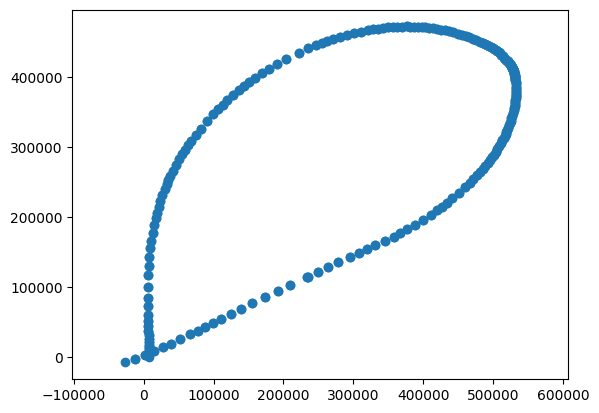

In [ ]:
# вар № 4
# без накопления, от угла кривой кажд кадра

coords = []

for i, (p1, p2) in enumerate(data[:], start=1):
    # угол наклона пути
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]
    alpha_curr = np.arctan2(dx, dy)
    L = p2[1]

    # ================================
    # найти след точку с учетом предыдущ
    if i > 1:
        p1 = p2_next
        alpha_curr += alpha_prev
    # ================================

    # найти след точку в сист коорд
    unit_vector = np.array([np.sin(alpha_curr), np.cos(alpha_curr)])
    p2_next = p1 + L * unit_vector

    alpha_prev = alpha_curr

    coords.append([p1, p2_next])
coords = np.vstack(coords)
plt.scatter(coords[:, 0], coords[:, 1])
plt.axis('equal');


4.323174579572897e-05
7.315621322413437e-05
0.00011264558636798348
0.0001478281933618332
0.00017085331034393956
0.00020609885889603805
0.0002594666635840402
0.00032970894837338146
0.00041219765628705513
0.0004924348568274869
0.0005546343416085548
0.0006192437900300026
0.0007238028237140316
0.0008742872909567908
0.0009863790720259897
0.0011524625171792284
0.0014011704484035705
0.0018032762348102163
0.0024771944899209834
0.0032478441433786407
0.003988783430562804
0.004618664867737412
0.004869032487544748
0.005358424708046643
0.005562319118794579
0.005716094763217472
0.005853232598838073
0.006017132364120528
0.006151368977446934
0.0062681407686774535
0.006365002788653171
0.006456418567811485
0.006532463560717427
0.00659854110854952
0.006644393550257767
0.00666885073763637
0.00668531955289303
0.006707161987392187
0.006736579638749371
0.0067763137050673074
0.0068204149081055
0.006860623346546337
0.0068973206432337945
0.0069374534461874755
0.0069745716825581824
0.007009680592564725
0.0070412

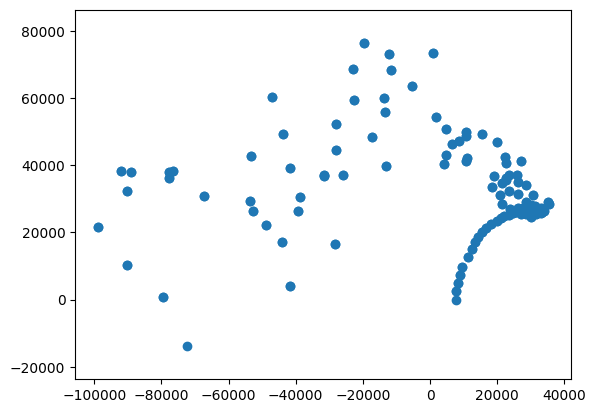

In [12]:
coords = []
x_norm = 7513
Ro = 0.
alpha_curr = 0.

for i, (p1, p2) in enumerate(data[100:], start=1):
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]
    # свой наклон
    alpha_curr = np.arctan2(dx, dy)
    # *******************************************
    L = p2[1]
    phi = np.arctan2(p1[0] - x_norm, L)
    ro = phi / L
    # *******************************************

    if i > 1:
        # начальн точка становится туда, где была видна из предыдущ кадра
        p1 = p1_next
        # *******************************************
        alpha_curr += L * Ro
        # print(alpha_curr)
        # *******************************************
        # из началь точки строится пройденное расст под своим углом
        unit_vector = np.array([np.sin(alpha_curr), np.cos(alpha_curr)])
        p2 = p1 + L * unit_vector
    # подмена новой начальной точки
    p1_next = p2

    Ro += ro
    print(Ro)
    coords.append([p1, p2])
coords = np.vstack(coords)
plt.scatter(coords[:, 0], coords[:, 1])
plt.axis('equal');
# for i in range(data.shape[0]):
#     try:
#         plt.text(coords[i, 0], coords[i, 1], f'{i}')
#     except IndexError:
#         pass
